In [2]:
import os

import numpy as np
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from aicsimageio import AICSImage

from cellpose import models

from skimage import io, filters, measure

from scipy import ndimage, optimize

import napari

18-Dec-25 14:05:06 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [3]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

## load fixed controls to find postbleach zero values

In [4]:
FIXED_GREEN = ["250113_mACmChPOLR2A_FRAP_FIXED/WELL5_mACPOLR2A_FIXED_GREEN/",
             "250113_mACmChPOLR2A_FRAP_FIXED/WELL3_mACmChPOLR2A_FIXED_GREEN/"]

FIXED_RED = ["250113_mACmChPOLR2A_FRAP_FIXED/WELL2_mChPOLR2A_FIXED_RED/",
             "250113_mACmChPOLR2A_FRAP_FIXED/WELL3_mACmChPOLR2A_FIXED_RED/"]

FIXED_GREEN_CELL = ['mACPOLR2A', 'mACmChPOLR2A']
FIXED_RED_CELL = ['mChPOLR2A', 'mACmChPOLR2A']

LS_RED_F = []

for i, n in enumerate(FIXED_RED):
    LS_RED_F.append([])
    for x in os.listdir(n):
        if x.endswith("csv"):
            LS_RED_F[i].append(x)
            
LS_GREEN_F = []

for i, n in enumerate(FIXED_GREEN):
    LS_GREEN_F.append([])
    for x in os.listdir(n):
        if x.endswith("csv"):
            LS_GREEN_F[i].append(x)

In [5]:
fixed_red_dfs = []


for i, n in enumerate(FIXED_RED):
    for c in LS_RED_F[i]:
        f = pd.read_csv(n + c)

        frame = f.index.tolist()
        t = f['Time::Relative Time!!R'][1:94]
        rfp_c = f['Channel1_R1_IntensityMean::mCher_R1_IntensityMean!!R'][1:94]
        rfp_b = f['Channel1_R2_IntensityMean::mCher_R2_IntensityMean!!R'][1:94]

        cell = FIXED_RED_CELL[i]
        
        date = n[:6]

        baseline_c = np.mean(rfp_c[:30])
        baseline_b = np.mean(rfp_b[:30])

        rfp_c_n = [100*(i/baseline_c) for i in rfp_c]
        rfp_b_n = [100*(i/baseline_b) for i in rfp_b]

        RFP_DF1 = pd.DataFrame({
            'DATE' : np.tile(date, len(t)),
            'FILE' : np.tile(n+c, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Control', len(t)),
            'INTENSITY' : rfp_c,
            'INTENSITY_PCT' : rfp_c_n})

        RFP_DF2 = pd.DataFrame({
            'DATE' : np.tile(date, len(t)),
            'FILE' : np.tile(n+c, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Bleached', len(t)),
            'INTENSITY' : rfp_b,
            'INTENSITY_PCT' : rfp_b_n })

        RFP_DF = pd.concat([RFP_DF1, RFP_DF2])

        fixed_red_dfs.append(RFP_DF)
        
mCherry_Fixed_Data = pd.concat(fixed_red_dfs)



fixed_green_dfs = []


for i, n in enumerate(FIXED_GREEN):
    for c in LS_GREEN_F[i]:
        f = pd.read_csv(n + c)

        frame = f.index.tolist()
        t = f['Time::Relative Time!!R'][1:94]
        gfp_c = f['Channel1_R1_IntensityMean::EGFP_R1_IntensityMean!!R'][1:94]
        gfp_b = f['Channel1_R2_IntensityMean::EGFP_R2_IntensityMean!!R'][1:94]

        cell = FIXED_GREEN_CELL[i]
        
        date = n[:6]

        baseline_c = np.mean(gfp_c[:30])
        baseline_b = np.mean(gfp_b[:30])

        gfp_c_n = [100*(i/baseline_c) for i in gfp_c]
        gfp_b_n = [100*(i/baseline_b) for i in gfp_b]

        GFP_DF1 = pd.DataFrame({
            'DATE' : np.tile(date, len(t)),
            'FILE' : np.tile(n+c, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Control', len(t)),
            'INTENSITY' : gfp_c,
            'INTENSITY_PCT' : gfp_c_n})

        GFP_DF2 = pd.DataFrame({
            'DATE' : np.tile(date, len(t)),
            'FILE' : np.tile(n+c, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Bleached', len(t)),
            'INTENSITY' : gfp_b,
            'INTENSITY_PCT' : gfp_b_n })

        GFP_DF = pd.concat([GFP_DF1, GFP_DF2])

        fixed_green_dfs.append(GFP_DF)
        
mClover_Fixed_Data = pd.concat(fixed_green_dfs)

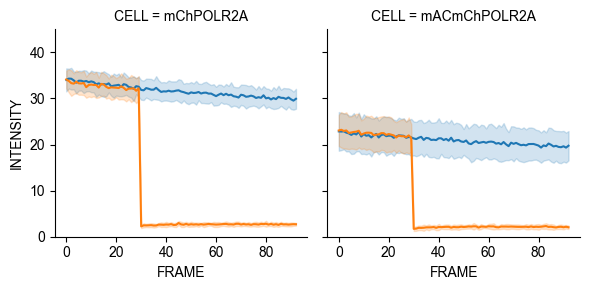

In [6]:
g = sns.FacetGrid(mCherry_Fixed_Data, col = 'CELL', ylim = (0,45))

g.map_dataframe(sns.lineplot, 
                x = 'FRAME', 
                y = 'INTENSITY', 
                hue = 'BLEACH',
               errorbar = 'sd')

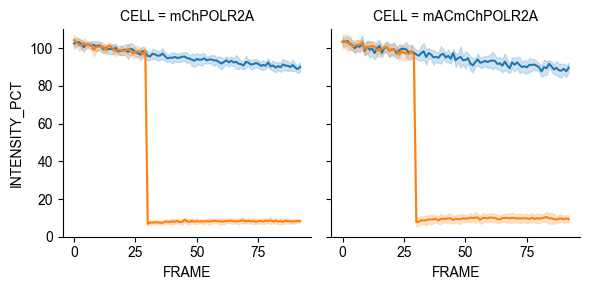

In [7]:
g = sns.FacetGrid(mCherry_Fixed_Data, col = 'CELL', ylim = (0,110))

g.map_dataframe(sns.lineplot, 
                x = 'FRAME', 
                y = 'INTENSITY_PCT', 
                hue = 'BLEACH',
               errorbar = 'sd')

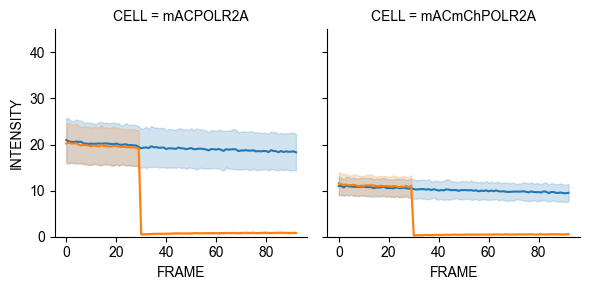

In [8]:
g = sns.FacetGrid(mClover_Fixed_Data, col = 'CELL', ylim = (0,45))

g.map_dataframe(sns.lineplot, 
                x = 'FRAME', 
                y = 'INTENSITY', 
                hue = 'BLEACH',
               errorbar = 'sd')

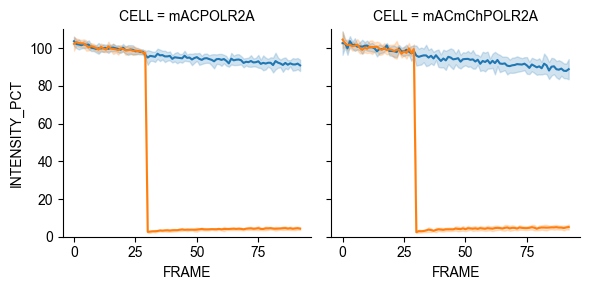

In [9]:
g = sns.FacetGrid(mClover_Fixed_Data, col = 'CELL', ylim = (0,110))

g.map_dataframe(sns.lineplot, 
                x = 'FRAME', 
                y = 'INTENSITY_PCT', 
                hue = 'BLEACH',
               errorbar = 'sd')

In [10]:
mCherry_Fixed_ZeroValues = mCherry_Fixed_Data.query('FRAME >= 30 & BLEACH == "Bleached"').groupby('CELL').INTENSITY_PCT.mean()
mClover_Fixed_ZeroValues = mClover_Fixed_Data.query('FRAME >= 30 & BLEACH == "Bleached"').groupby('CELL').INTENSITY_PCT.mean()

In [11]:
mCherry_Fixed_ZeroValues

CELL
mACmChPOLR2A    9.557799
mChPOLR2A       8.120634
Name: INTENSITY_PCT, dtype: float64

In [12]:
mClover_Fixed_ZeroValues

CELL
mACPOLR2A       3.935304
mACmChPOLR2A    4.309067
Name: INTENSITY_PCT, dtype: float64

## define subdirectories and experimental conditions

In [13]:
SUBDIRS_GREEN = ["250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_24HR_GREEN/",
                 "250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_VEH_24HR_GREEN/",
                "250123_mACmChPOLR2A_FRAP/WELL01_mACmChPOLR2A_VEH_24HR_GREEN/",
                "250123_mACmChPOLR2A_FRAP/WELL05_mACPOLR2A_VEH_24HR/",
                 "250124_mACmChPOLR2A_FRAP/WELL01_mACmChPOLR2A_VEH_24HR_GREEN/",
                 "250124_mACmChPOLR2A_FRAP/WELL05_mACPOLR2A_VEH_24HR_GREEN/"]

SUBDIRS_RED = ["250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_VEH_24HR_RED/",
                 "250113_mACmChPOLR2A_FRAP/WELL04_mACmChPOLR2A_5PH_24HR_RED/",
                "250113_mACmChPOLR2A_FRAP/WELL06_mChPOLR2A_VEH_90MIN_RED/",
                "250113_mACmChPOLR2A_FRAP/WELL07_mACmChPOLR2A_5PH_90MIN_RED/",
              "250123_mACmChPOLR2A_FRAP/WELL01_mACmChPOLR2A_VEH_24HR_RED/",
              "250123_mACmChPOLR2A_FRAP/WELL02_mACmChPOLR2A_5PH_24HR_RED/",
              "250123_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_5PH_90MIN_RED/",
              "250123_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_24HR/",
              "250124_mACmChPOLR2A_FRAP/WELL01_mACmChPOLR2A_VEH_24HR_RED/",
              "250124_mACmChPOLR2A_FRAP/WELL02_mACmChPOLR2A_5PH_24HR_RED/",
              "250124_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_5PH_90MIN_RED/",
              "250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_24HR_RED/"]


In [14]:
SUBDIRS_GREEN_COND = ['mACPOLR2A VEH',
                      'mACmChPOLR2A VEH',
                      'mACmChPOLR2A VEH',
                      'mACPOLR2A VEH',
                      'mACmChPOLR2A VEH',
                      'mACPOLR2A VEH']

SUBDIRS_RED_COND = ["mACmChPOLR2A VEH",
                 "mACmChPOLR2A 5PH 24HR",
                "mChPOLR2A VEH",
                "mACmChPOLR2A 5PH 90MIN",
              "mACmChPOLR2A VEH",
              "mACmChPOLR2A 5PH 24HR",
              "mACmChPOLR2A 5PH 90MIN",
              "mChPOLR2A VEH",
              "mACmChPOLR2A VEH",
              "mACmChPOLR2A 5PH 24HR",
              "mACmChPOLR2A 5PH 90MIN",
              "mChPOLR2A VEH"]

SUBDIRS_GREEN_CELL = ["mACPOLR2A",
                 "mACmChPOLR2A",
                "mACmChPOLR2A",
                "mACPOLR2A",
              "mACmChPOLR2A",
              "mACPOLR2A"]

SUBDIRS_RED_CELL = ["mACmChPOLR2A",
                 "mACmChPOLR2A",
                "mChPOLR2A",
                "mACmChPOLR2A",
              "mACmChPOLR2A",
              "mACmChPOLR2A",
              "mACmChPOLR2A",
              "mChPOLR2A",
              "mACmChPOLR2A",
              "mACmChPOLR2A",
              "mACmChPOLR2A",
              "mChPOLR2A"]




## loading and quickly checking mCherry / mClover fluorescence intensity

In [15]:
LS_GREEN = []

for i, n in enumerate(SUBDIRS_GREEN):
    LS_GREEN.append([])
    for x in os.listdir(n):
        if x.endswith("SNAP.czi"):
            LS_GREEN[i].append(x)
            
            
LS_RED = []

for i, n in enumerate(SUBDIRS_RED):
    LS_RED.append([])
    for x in os.listdir(n):
        if x.endswith("SNAP.czi"):
            LS_RED[i].append(x)

In [16]:
files = []
conditions = []
dates = []

ars = []
ints_red = []
ints_green = []

green_labels = []


for i, n in enumerate(SUBDIRS_GREEN):
    for c in tqdm(LS_GREEN[i]):
        img = AICSImage(n + "/" + c).get_image_data('CYX')
        
        t = filters.threshold_mean(filters.gaussian(img[1], sigma = 1))
        h = filters.gaussian(img[1], sigma = 1) > t
        mask = ndimage.label(h)[0]
        
        if len(np.unique(mask)) > 1:
            props = measure.regionprops_table(mask, 
                                      intensity_image = np.moveaxis(img,0,2),
                                     properties = ['label', 'area', 'intensity_mean'])
            bigloc = np.argmax(props['area']) + 1
            ar = props['area'][props['label'] == bigloc][0]
            int_red = props['intensity_mean-0'][props['label'] == bigloc][0]
            int_green = props['intensity_mean-1'][props['label'] == bigloc][0]
            
            green_labels.append(mask == bigloc)

            files.append(n+c)
            conditions.append(SUBDIRS_GREEN_COND[i])
            dates.append(n[:6])
            ars.append(ar)
            ints_red.append(int_red)
            ints_green.append(int_green)
            
mClover_On_DF = pd.DataFrame({'DATE' : dates,
                              'CONDITION' : conditions,
                             'FILE': files,
                             'AREA' : ars,
                             'INTENSITY_MCHERRY' : ints_red,
                            'INTENSITY_MCLOVER' : ints_green})

100%|███████████████████████████████████████████| 25/25 [00:01<00:00, 21.62it/s]


In [17]:
del green_labels

In [18]:
#Green_Labels = np.asarray(green_labels)
#v = napari.Viewer()
#v.add_image(Green_Labels)

In [19]:
mClover_On_DF.groupby('CONDITION').count()

,DATE,FILE,AREA,INTENSITY_MCHERRY,INTENSITY_MCLOVER
CONDITION,,,,,
mACPOLR2A VEH,45,45,45,45,45
mACmChPOLR2A VEH,45,45,45,45,45


In [20]:
files = []
conditions = []
dates = []

ars = []
ints_red = []
ints_green = []

red_labels = []

for i, n in enumerate(SUBDIRS_RED):
    for c in tqdm(LS_RED[i]):
        img = AICSImage(n + "/" + c).get_image_data('CYX')
        
        t = filters.threshold_mean(filters.gaussian(img[0], sigma = 1))
        h = filters.gaussian(img[0], sigma = 1) > t
        mask = ndimage.label(h)[0]
        
        if len(np.unique(mask)) > 1:
            props = measure.regionprops_table(mask, 
                                      intensity_image = np.moveaxis(img,0,2),
                                     properties = ['label', 'area', 'intensity_mean'])
            bigloc = np.argmax(props['area']) + 1
            ar = props['area'][props['label'] == bigloc][0]
            int_red = props['intensity_mean-0'][props['label'] == bigloc][0]
            int_green = props['intensity_mean-1'][props['label'] == bigloc][0]
            
            l = (mask == bigloc)
            l_f = ndimage.binary_fill_holes(l)
            
            ar = np.count_nonzero(l_f)

            files.append(n+c)
            conditions.append(SUBDIRS_RED_COND[i])
            dates.append(n[:6])
            ars.append(ar)
            ints_red.append(int_red)
            ints_green.append(int_green)
            
mCherry_On_DF = pd.DataFrame({'DATE' : dates,
                              'CONDITION' : conditions,
                             'FILE': files,
                             'AREA' : ars,
                             'INTENSITY_MCHERRY' : ints_red,
                            'INTENSITY_MCLOVER' : ints_green})

100%|███████████████████████████████████████████| 23/23 [00:01<00:00, 21.41it/s]


In [21]:
del red_labels

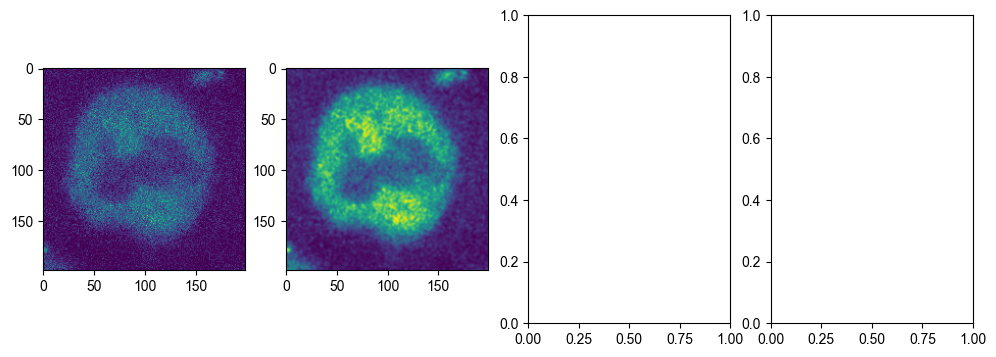

In [22]:
f, a = plt.subplots( ncols = 4, figsize = (12,4) )

a[0].imshow(img[0])
a[1].imshow(filters.gaussian(img[0], sigma = 1))
#a[2].imshow(red_labels[0])
#a[3].imshow(red_labels_filled[0])

In [23]:
#Red_Labels = np.asarray(red_labels)
#Red_Labels_Filled = np.asarray(red_labels_filled)
#v = napari.Viewer()
#v.add_image(Red_Labels_Filled)

In [24]:
mCherry_On_DF.groupby('CONDITION').count()

,DATE,FILE,AREA,INTENSITY_MCHERRY,INTENSITY_MCLOVER
CONDITION,,,,,
mACmChPOLR2A 5PH 24HR,45,45,45,45,45
mACmChPOLR2A 5PH 90MIN,45,45,45,45,45
mACmChPOLR2A VEH,45,45,45,45,45
mChPOLR2A VEH,45,45,45,45,45


/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/2689830302.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[0].set_xticklabels(xlabels, rotation=90)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/2689830302.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[1].set_xticklabels(xlabels, rotation=90)


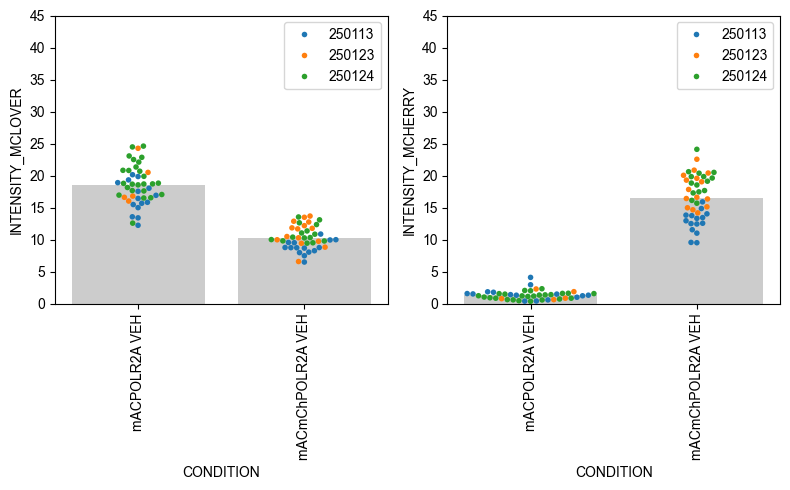

In [25]:
f , a = plt.subplots(ncols = 2, figsize = (8,5))

sns.swarmplot(mClover_On_DF, x = 'CONDITION', hue = 'DATE', y = 'INTENSITY_MCLOVER', ax = a[0], size = 4)
sns.swarmplot(mClover_On_DF, x = 'CONDITION', hue = 'DATE', y = 'INTENSITY_MCHERRY', ax = a[1], size = 4)

sns.barplot(mClover_On_DF, x = 'CONDITION', y = 'INTENSITY_MCLOVER', ax = a[0], alpha = 0.2, errorbar = None, color = 'black')
sns.barplot(mClover_On_DF, x = 'CONDITION', y = 'INTENSITY_MCHERRY', ax = a[1], alpha = 0.2, errorbar = None, color = 'black')

a[0].set_ylim(0,45)
a[1].set_ylim(0,45)

xlabels = a[0].get_xticklabels()

a[0].set_xticklabels(xlabels, rotation=90)
a[1].set_xticklabels(xlabels, rotation=90)

plt.tight_layout()

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/1103184650.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[0].set_xticklabels(xlabels, rotation=90)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/1103184650.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[1].set_xticklabels(xlabels, rotation=90)


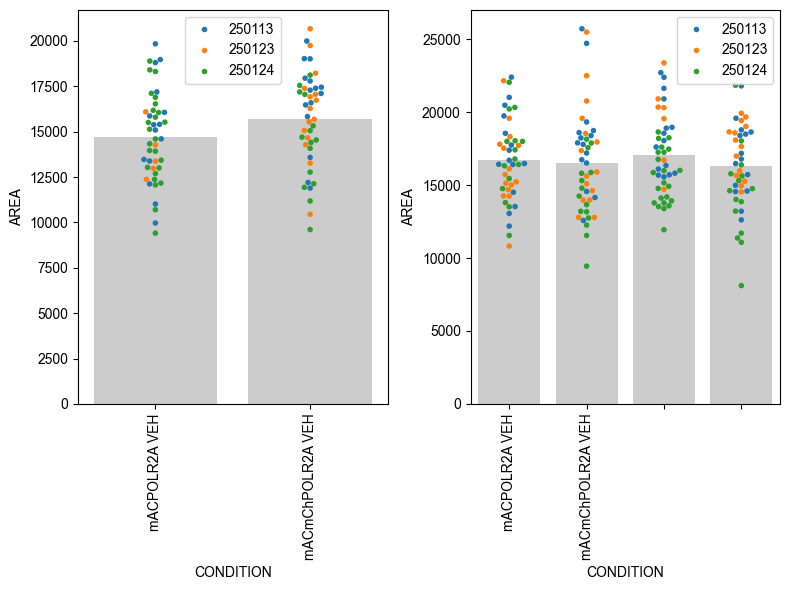

In [26]:
f , a = plt.subplots(ncols = 2, figsize = (8,6))

sns.swarmplot(mClover_On_DF, x = 'CONDITION', hue = 'DATE', y = 'AREA', ax = a[0], size = 4)
sns.barplot(mClover_On_DF, x = 'CONDITION', y = 'AREA', ax = a[0], alpha = 0.2, errorbar = None, color = 'black')

sns.swarmplot(mCherry_On_DF, x = 'CONDITION', hue = 'DATE', y = 'AREA', ax = a[1], size = 4)
sns.barplot(mCherry_On_DF, x = 'CONDITION', y = 'AREA', ax = a[1], alpha = 0.2, errorbar = None, color = 'black')

xlabels = a[0].get_xticklabels()

a[0].set_xticklabels(xlabels, rotation=90)
a[1].set_xticklabels(xlabels, rotation=90)

plt.tight_layout()

In [27]:
mCherry_On_DF.CONDITION.unique()

array(['mACmChPOLR2A VEH', 'mACmChPOLR2A 5PH 24HR', 'mChPOLR2A VEH',
       'mACmChPOLR2A 5PH 90MIN'], dtype=object)

/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/67936616.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[0].set_xticklabels(xlabels, rotation=90)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/67936616.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a[1].set_xticklabels(xlabels, rotation=90)
/Users/alexandergillis/opt/anaconda3/envs/pyimg310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  war

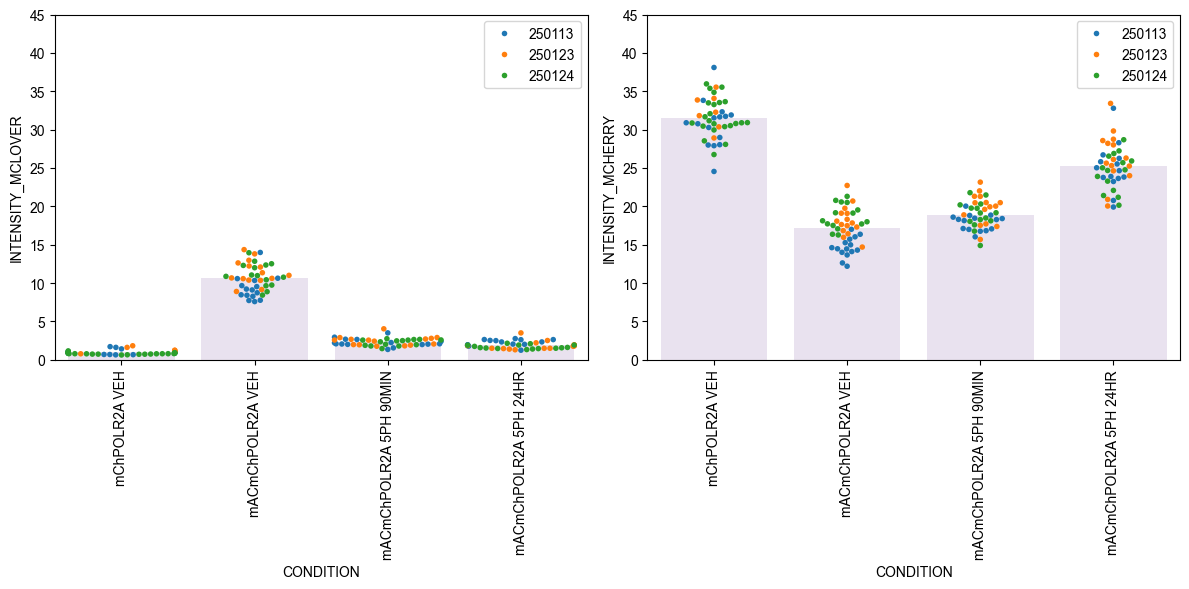

In [28]:
f , a = plt.subplots(ncols = 2, figsize = (12,6))

o = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH', 'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR']

sns.swarmplot(mCherry_On_DF, x = 'CONDITION', order = o, hue = 'DATE', y = 'INTENSITY_MCLOVER', ax = a[0], size = 4)
sns.swarmplot(mCherry_On_DF, x = 'CONDITION', order = o, hue = 'DATE', y = 'INTENSITY_MCHERRY', ax = a[1], size = 4)

sns.barplot(mCherry_On_DF, x = 'CONDITION', y = 'INTENSITY_MCLOVER', ax = a[0], alpha = 0.2, errorbar = None)
sns.barplot(mCherry_On_DF, x = 'CONDITION', y = 'INTENSITY_MCHERRY', ax = a[1], alpha = 0.2, errorbar = None)

a[0].set_ylim(0,45)
a[1].set_ylim(0,45)

xlabels = a[0].get_xticklabels()

a[0].set_xticklabels(xlabels, rotation=90)
a[1].set_xticklabels(xlabels, rotation=90)

plt.tight_layout()

In [29]:
mCherry_On_DF

,DATE,CONDITION,FILE,AREA,INTENSITY_MCHERRY,INTENSITY_MCLOVER
0,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,22390,16.363945,10.637779
1,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,17738,15.723805,8.477366
2,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,16421,15.269736,8.281718
3,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,16406,17.014038,10.585212
4,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,13053,14.473933,9.543393
...,...,...,...,...,...,...
175,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,15984,29.957269,0.747533
176,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,18633,30.792919,0.942392
177,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,14182,28.534446,0.634483
178,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,16005,32.074407,1.051759


In [30]:
mClover_On_DF.drop('FILE',axis = 1).groupby(['DATE','CONDITION']).mean().reset_index()

,DATE,CONDITION,AREA,INTENSITY_MCHERRY,INTENSITY_MCLOVER
0,250113,mACPOLR2A VEH,15145.066667,1.577620,16.584851
1,250113,mACmChPOLR2A VEH,16638.533333,12.781494,8.827996
2,250123,mACPOLR2A VEH,13817.000000,1.331412,18.865736
3,250123,mACmChPOLR2A VEH,16130.466667,17.889481,11.075094
4,250124,mACPOLR2A VEH,14641.360000,1.254415,19.562269
5,250124,mACmChPOLR2A VEH,14376.066667,19.068387,10.996153


In [31]:
mCherry_On_DF.drop('FILE',axis = 1).groupby(['DATE','CONDITION']).mean().reset_index()

,DATE,CONDITION,AREA,INTENSITY_MCHERRY,INTENSITY_MCLOVER
0,250113,mACmChPOLR2A 5PH 24HR,18069.933333,24.940693,2.216824
1,250113,mACmChPOLR2A 5PH 90MIN,16781.933333,17.912844,2.260728
2,250113,mACmChPOLR2A VEH,17101.333333,14.656724,9.341366
3,250113,mChPOLR2A VEH,18322.400000,30.696832,1.022482
4,250123,mACmChPOLR2A 5PH 24HR,17122.266667,26.330198,1.875820
5,250123,mACmChPOLR2A 5PH 90MIN,17834.666667,19.734702,2.477000
6,250123,mACmChPOLR2A VEH,16282.200000,18.128554,11.410607
7,250123,mChPOLR2A VEH,19408.142857,32.402746,1.252727
8,250124,mACmChPOLR2A 5PH 24HR,14371.800000,24.495569,1.687831
9,250124,mACmChPOLR2A 5PH 90MIN,14375.800000,18.918414,2.274428


## loading FRAP results

In [32]:
LS_GREEN = []

for i, n in enumerate(SUBDIRS_GREEN):
    LS_GREEN.append([])
    for x in os.listdir(n):
        if x.endswith("csv"):
            LS_GREEN[i].append(x)
            
            
LS_RED = []

for i, n in enumerate(SUBDIRS_RED):
    LS_RED.append([])
    for x in os.listdir(n):
        if x.endswith("csv"):
            LS_RED[i].append(x)

In [33]:
green_dfs = []

for i, n in enumerate(SUBDIRS_GREEN):
    for c in LS_GREEN[i]:
        f = pd.read_csv(n + c)
        
        frame = f.index.tolist()
        t = f['Time::Relative Time!!R'][1:94]
        gfp_c = f['Channel1_R1_IntensityMean::EGFP_R1_IntensityMean!!R'][1:94]
        gfp_b = f['Channel1_R2_IntensityMean::EGFP_R2_IntensityMean!!R'][1:94]
        
        condition = SUBDIRS_GREEN_COND[i]
        cell = SUBDIRS_GREEN_CELL[i]
        well = c[:6]
        
        baseline_c = np.mean(gfp_c[:30])
        baseline_b = np.mean(gfp_b[:30])
        
        gfp_c_n = [100*(i/baseline_c) for i in gfp_c]
        gfp_b_n = [100*(i/baseline_b) for i in gfp_b]
        
        GFP_DF1 = pd.DataFrame({
            'FILE' : np.tile(n+c, len(t)),
            'DATE' : np.tile((n+c)[:6], len(t)),
            'CONDITION' : np.tile(condition, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Control', len(t)),
            'INTENSITY' : gfp_c,
            'INTENSITY_PCT' : gfp_c_n })
        
        GFP_DF2 = pd.DataFrame({
            'FILE' : np.tile(n+c, len(t)),
            'DATE' : np.tile((n+c)[:6], len(t)),
            'CONDITION' : np.tile(condition, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Bleached', len(t)),
            'INTENSITY' : gfp_b,
            'INTENSITY_PCT' : gfp_b_n })
        
        GFP_DF = pd.concat([GFP_DF1, GFP_DF2])
        
        green_dfs.append(GFP_DF)
        
mClover_Data = pd.concat(green_dfs)


red_dfs = []

for i, n in enumerate(SUBDIRS_RED):
    for c in LS_RED[i]:
        f = pd.read_csv(n + c)
        
        frame = f.index.tolist()
        t = f['Time::Relative Time!!R'][1:94]
        rfp_c = f['Channel1_R1_IntensityMean::mCher_R1_IntensityMean!!R'][1:94]
        rfp_b = f['Channel1_R2_IntensityMean::mCher_R2_IntensityMean!!R'][1:94]
        
        condition = SUBDIRS_RED_COND[i]
        cell = SUBDIRS_RED_CELL[i]
        well = c[:6]
        
        baseline_c = np.mean(rfp_c[:30])
        baseline_b = np.mean(rfp_b[:30])
        
        rfp_c_n = [100*(i/baseline_c) for i in rfp_c]
        rfp_b_n = [100*(i/baseline_b) for i in rfp_b]
        
        RFP_DF1 = pd.DataFrame({
            'FILE' : np.tile(n+c, len(t)),
            'DATE' : np.tile((n+c)[:6], len(t)),
            'CONDITION' : np.tile(condition, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'WELL' : np.tile(well, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Control', len(t)),
            'INTENSITY' : rfp_c,
            'INTENSITY_PCT' : rfp_c_n})
        
        RFP_DF2 = pd.DataFrame({
            'FILE' : np.tile(n+c, len(t)),
            'DATE' : np.tile((n+c)[:6], len(t)),
            'CONDITION' : np.tile(condition, len(t)),
            'CELL' : np.tile(cell, len(t)),
            'WELL' : np.tile(well, len(t)),
            'FRAME' : range(0,len(t)),
            'TIME' : t,
            'BLEACH' : np.tile('Bleached', len(t)),
            'INTENSITY' : rfp_b,
            'INTENSITY_PCT' : rfp_b_n })
        
        RFP_DF = pd.concat([RFP_DF1, RFP_DF2])
        
        red_dfs.append(RFP_DF)
        
mCherry_Data = pd.concat(red_dfs)



In [34]:
mClover_Data

,FILE,DATE,CONDITION,CELL,FRAME,TIME,BLEACH,INTENSITY,INTENSITY_PCT
1,250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_...,250113,mACPOLR2A VEH,mACPOLR2A,0,0,Control,22.537838,100.411407
2,250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_...,250113,mACPOLR2A VEH,mACPOLR2A,1,356.9868,Control,22.413514,99.857513
3,250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_...,250113,mACPOLR2A VEH,mACPOLR2A,2,666.3098,Control,22.278378,99.255454
4,250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_...,250113,mACPOLR2A VEH,mACPOLR2A,3,959.745,Control,22.040541,98.195830
5,250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_...,250113,mACPOLR2A VEH,mACPOLR2A,4,1269.0682,Control,23.062162,102.747396
...,...,...,...,...,...,...,...,...,...
89,250124_mACmChPOLR2A_FRAP/WELL05_mACPOLR2A_VEH_...,250124,mACPOLR2A VEH,mACPOLR2A,88,28255.6962,Bleached,9.561680,33.061076
90,250124_mACmChPOLR2A_FRAP/WELL05_mACPOLR2A_VEH_...,250124,mACPOLR2A VEH,mACPOLR2A,89,28565.0194,Bleached,9.196850,31.799619
91,250124_mACmChPOLR2A_FRAP/WELL05_mACPOLR2A_VEH_...,250124,mACPOLR2A VEH,mACPOLR2A,90,28858.4546,Bleached,9.490814,32.816045
92,250124_mACmChPOLR2A_FRAP/WELL05_mACPOLR2A_VEH_...,250124,mACPOLR2A VEH,mACPOLR2A,91,29167.7775,Bleached,9.346457,32.316907


In [35]:
mClover_Data.query('FRAME == 0 & BLEACH == "Bleached"')[['DATE','CONDITION','CELL']].groupby(['DATE','CONDITION']).count().reset_index()

,DATE,CONDITION,CELL
0,250113,mACPOLR2A VEH,15
1,250113,mACmChPOLR2A VEH,15
2,250123,mACPOLR2A VEH,5
3,250123,mACmChPOLR2A VEH,15
4,250124,mACPOLR2A VEH,25
5,250124,mACmChPOLR2A VEH,15


In [36]:
mCherry_Data.query('FRAME == 0 & BLEACH == "Bleached"')[['DATE','CONDITION','WELL']].groupby(['DATE','CONDITION']).count().reset_index()

,DATE,CONDITION,WELL
0,250113,mACmChPOLR2A 5PH 24HR,15
1,250113,mACmChPOLR2A 5PH 90MIN,15
2,250113,mACmChPOLR2A VEH,15
3,250113,mChPOLR2A VEH,15
4,250123,mACmChPOLR2A 5PH 24HR,15
5,250123,mACmChPOLR2A 5PH 90MIN,15
6,250123,mACmChPOLR2A VEH,15
7,250123,mChPOLR2A VEH,6
8,250124,mACmChPOLR2A 5PH 24HR,15
9,250124,mACmChPOLR2A 5PH 90MIN,15


## plotting raw FRAP results

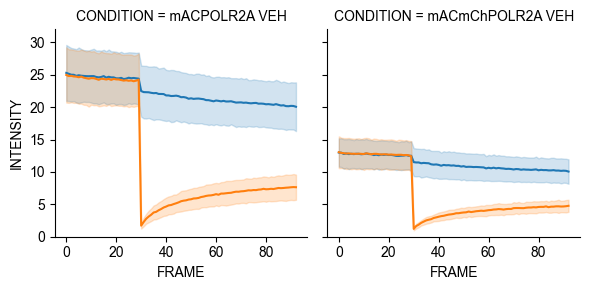

In [37]:
g = sns.FacetGrid(mClover_Data, col = 'CONDITION', ylim = (0,32))

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY', hue = 'BLEACH', errorbar = 'sd')

In [38]:
frametime = mClover_Data[['FRAME','TIME']]
frametime['TIME'] = frametime['TIME'].astype('float')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/4151379948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frametime['TIME'] = frametime['TIME'].astype('float')


In [39]:
frames = frametime.groupby('FRAME').mean().reset_index()

In [40]:
mClover_Data['TIME_MEAN'] = (mClover_Data['FRAME'].map(dict(zip(frames.FRAME.tolist(), frames.TIME.tolist()))))/1000

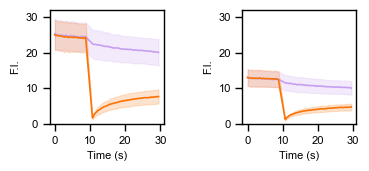

In [41]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.8))

pal = sns.color_palette(['xkcd:lavender', 'xkcd:orange'])

sns.lineplot(mClover_Data.query('CONDITION == "mACPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[0])

sns.lineplot(mClover_Data.query('CONDITION == "mACmChPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[1])


for i in [0,1]:
    a[i].set_box_aspect(1)
    a[i].set_ylim(0,32)
    a[i].set_xticks([0,10,20,30])
    a[i].set_ylabel('F.I.', fontsize = 8)
    a[i].set_xlabel('Time (s)', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)
    
    
plt.tight_layout()

plt.savefig('mclover_frap_rawfi.svg')

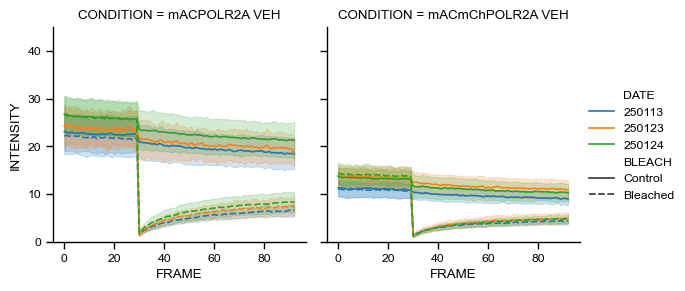

In [42]:
g = sns.FacetGrid(mClover_Data, col = 'CONDITION', ylim = (0,45))

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY', hue = 'DATE', style = 'BLEACH', errorbar = 'sd')
g.add_legend()

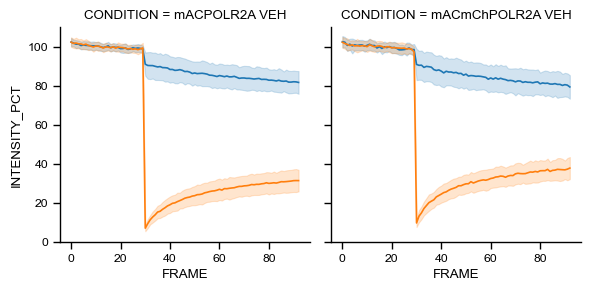

In [43]:
g = sns.FacetGrid(mClover_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY_PCT', hue = 'BLEACH', errorbar = 'sd')

In [44]:
frametime = mCherry_Data[['FRAME','TIME']]
frametime['TIME'] = frametime['TIME'].astype('float')
frames = frametime.groupby('FRAME').mean().reset_index()
mCherry_Data['TIME_MEAN'] = (mCherry_Data['FRAME'].map(dict(zip(frames.FRAME.tolist(), frames.TIME.tolist()))))/1000

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/852492344.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frametime['TIME'] = frametime['TIME'].astype('float')


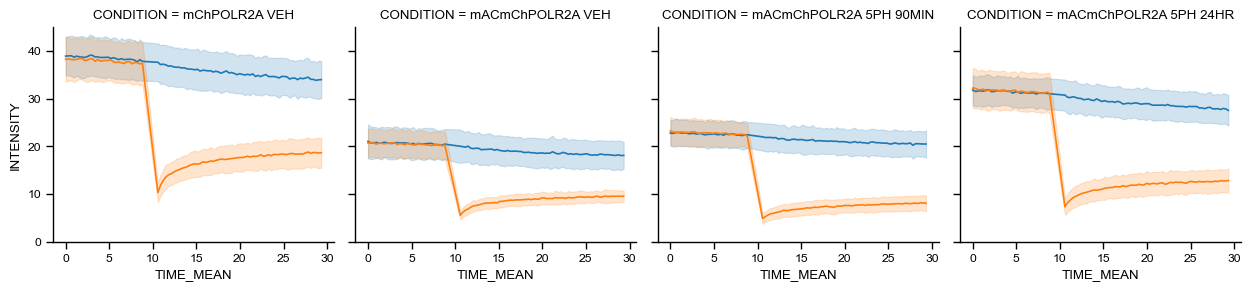

In [45]:
g = sns.FacetGrid(mCherry_Data, col = 'CONDITION', col_order = o, ylim = (0,45), aspect = 1.05)

g.map_dataframe(sns.lineplot, x = 'TIME_MEAN', y = 'INTENSITY', hue = 'BLEACH', errorbar = 'sd')

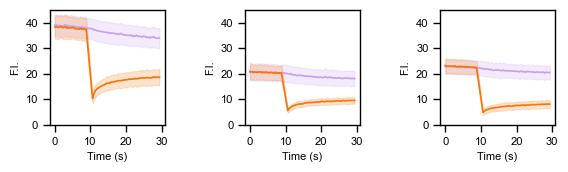

In [46]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (6,1.8))

pal = sns.color_palette(['xkcd:lavender', 'xkcd:orange'])

sns.lineplot(mCherry_Data.query('CONDITION == "mChPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[0])

sns.lineplot(mCherry_Data.query('CONDITION == "mACmChPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[1])

sns.lineplot(mCherry_Data.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[2])


for i in [0,1,2]:
    a[i].set_box_aspect(1)
    a[i].set_ylim(0,45)
    a[i].set_xticks([0,10,20,30])
    a[i].set_ylabel('F.I.', fontsize = 8)
    a[i].set_xlabel('Time (s)', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)
    
    
plt.tight_layout()

plt.savefig('mcherry_frap_rawfi.svg')

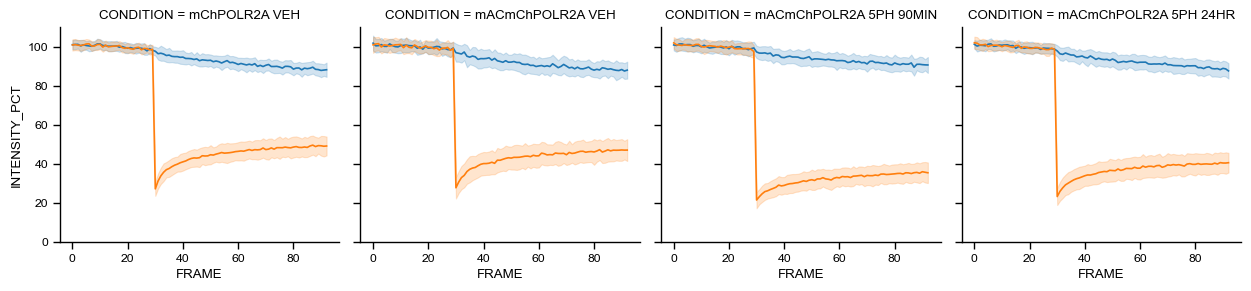

In [47]:
g = sns.FacetGrid(mCherry_Data, col = 'CONDITION', col_order = o, ylim = (0,110), aspect = 1.05)

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY_PCT', hue = 'BLEACH', errorbar = 'sd')

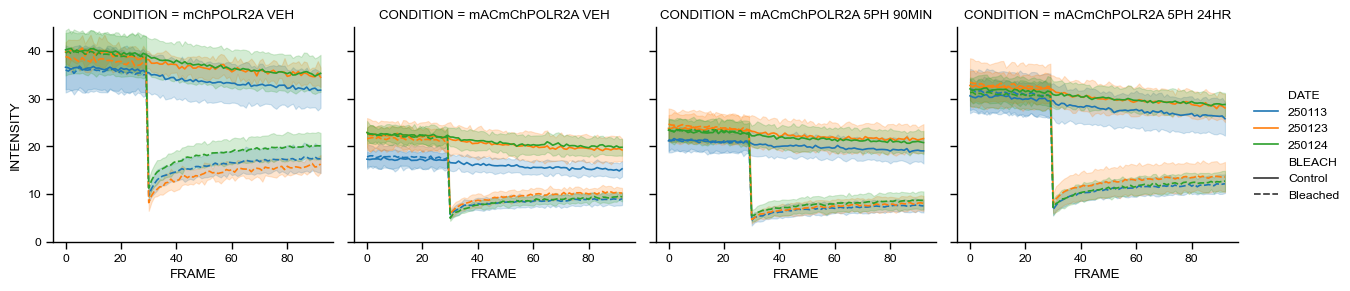

In [48]:
g = sns.FacetGrid(mCherry_Data, col = 'CONDITION', col_order = o, ylim = (0,45), aspect = 1.05)

g.map_dataframe(sns.lineplot, x = 'FRAME', y = 'INTENSITY', hue = 'DATE', style = 'BLEACH', errorbar = 'sd')

g.add_legend()

## plot raw FRAP data with fixed control overlaid

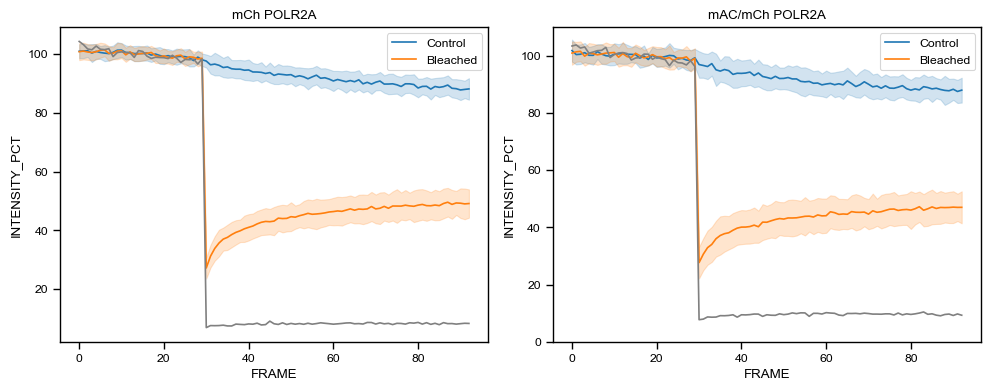

In [49]:
f, a = plt.subplots(ncols = 2, figsize = (10,4))

a[0].set_title('mCh POLR2A')
a[1].set_title('mAC/mCh POLR2A')

sns.lineplot(mCherry_Data.query('CONDITION == "mChPOLR2A VEH"'),
             x = 'FRAME',
             y = 'INTENSITY_PCT',
            hue = 'BLEACH',
            errorbar = 'sd',
            ax = a[0])

sns.lineplot(mCherry_Fixed_Data.query('CELL == "mChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'FRAME', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[0])


sns.lineplot(mCherry_Data.query('CONDITION == "mACmChPOLR2A VEH"'),
             x = 'FRAME',
             y = 'INTENSITY_PCT',
            hue = 'BLEACH',
            errorbar = 'sd',
            ax = a[1])

sns.lineplot(mCherry_Fixed_Data.query('CELL == "mACmChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'FRAME', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[1])


plt.ylim(0,110)
plt.tight_layout()

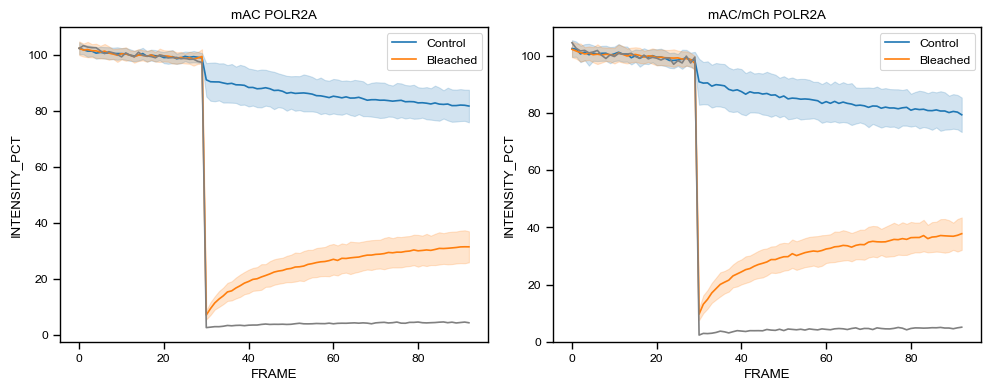

In [50]:
f, a = plt.subplots(ncols = 2, figsize = (10,4))

a[0].set_title('mAC POLR2A')
a[1].set_title('mAC/mCh POLR2A')

sns.lineplot(mClover_Data.query('CONDITION == "mACPOLR2A VEH"'),
             x = 'FRAME',
             y = 'INTENSITY_PCT',
            hue = 'BLEACH',
            errorbar = 'sd',
            ax = a[0])

sns.lineplot(mClover_Fixed_Data.query('CELL == "mACPOLR2A" & BLEACH == "Bleached"'), 
             x = 'FRAME', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[0])


sns.lineplot(mClover_Data.query('CONDITION == "mACmChPOLR2A VEH"'),
             x = 'FRAME',
             y = 'INTENSITY_PCT',
            hue = 'BLEACH',
            errorbar = 'sd',
            ax = a[1])

sns.lineplot(mClover_Fixed_Data.query('CELL == "mACmChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'FRAME', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[1])


plt.ylim(0,110)
plt.tight_layout()

In [51]:
mclover_fixed_frames = mClover_Fixed_Data[['FRAME','TIME']]
mclover_fixed_frames['TIME'] =  mclover_fixed_frames['TIME'].astype(float)
frametime = mclover_fixed_frames.groupby('FRAME').mean().reset_index()
mClover_Fixed_Data['TIME_MEAN'] = (mClover_Fixed_Data['FRAME'].map(dict(zip(frametime.FRAME, frametime.TIME))))/1000

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/379659708.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mclover_fixed_frames['TIME'] =  mclover_fixed_frames['TIME'].astype(float)


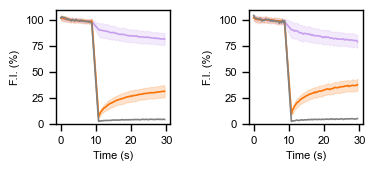

In [52]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (4,1.8))

pal = sns.color_palette(['xkcd:lavender', 'xkcd:orange'])

sns.lineplot(mClover_Data.query('CONDITION == "mACPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY_PCT',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[0])

sns.lineplot(mClover_Fixed_Data.query('CELL == "mACPOLR2A" & BLEACH == "Bleached"'), 
             x = 'TIME_MEAN', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[0])

sns.lineplot(mClover_Data.query('CONDITION == "mACmChPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY_PCT',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[1])

sns.lineplot(mClover_Fixed_Data.query('CELL == "mACmChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'TIME_MEAN', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[1])


for i in [0,1]:
    a[i].set_box_aspect(1)
    a[i].set_ylim(0,110)
    a[i].set_xticks([0,10,20,30])
    a[i].set_ylabel('F.I. (%)', fontsize = 8)
    a[i].set_xlabel('Time (s)', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)
    
    
plt.tight_layout()

plt.savefig('mclover_frap_normalisationstep.svg')

In [53]:
mcherry_fixed_frames = mCherry_Fixed_Data[['FRAME','TIME']]
mcherry_fixed_frames['TIME'] =  mcherry_fixed_frames['TIME'].astype(float)
frametime = mcherry_fixed_frames.groupby('FRAME').mean().reset_index()
mCherry_Fixed_Data['TIME_MEAN'] = (mCherry_Fixed_Data['FRAME'].map(dict(zip(frametime.FRAME, frametime.TIME))))/1000

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/2621212238.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mcherry_fixed_frames['TIME'] =  mcherry_fixed_frames['TIME'].astype(float)


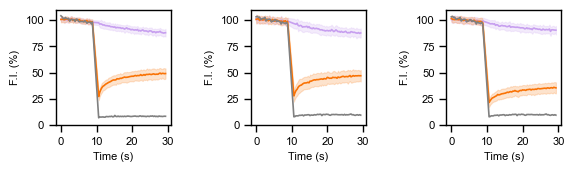

In [54]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (6,1.8))

pal = sns.color_palette(['xkcd:lavender', 'xkcd:orange'])

sns.lineplot(mCherry_Data.query('CONDITION == "mChPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY_PCT',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[0])

sns.lineplot(mCherry_Fixed_Data.query('CELL == "mChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'TIME_MEAN', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[0])

sns.lineplot(mCherry_Data.query('CONDITION == "mACmChPOLR2A VEH"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY_PCT',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[1])

sns.lineplot(mCherry_Fixed_Data.query('CELL == "mACmChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'TIME_MEAN', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[1])

sns.lineplot(mCherry_Data.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"'),
             x = 'TIME_MEAN',
             y = 'INTENSITY_PCT',
             hue = 'BLEACH', palette = pal, legend = False,
             errorbar = 'sd',
             ax = a[2])

sns.lineplot(mCherry_Fixed_Data.query('CELL == "mACmChPOLR2A" & BLEACH == "Bleached"'), 
             x = 'TIME_MEAN', 
             y = 'INTENSITY_PCT',
            color = 'grey',
             errorbar = None,
            ax = a[2])


for i in [0,1,2]:
    a[i].set_box_aspect(1)
    a[i].set_ylim(0,110)
    a[i].set_xticks([0,10,20,30])
    a[i].set_ylabel('F.I. (%)', fontsize = 8)
    a[i].set_xlabel('Time (s)', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)
    
    
plt.tight_layout()

plt.savefig('mcherry_frap_normalisationstep.svg')

## check the variation in framerate is negligible

Frame is slightly variable between traces. Check this variation then construct mean time for all traces.

Text(0, 0.5, 'time (ms)')

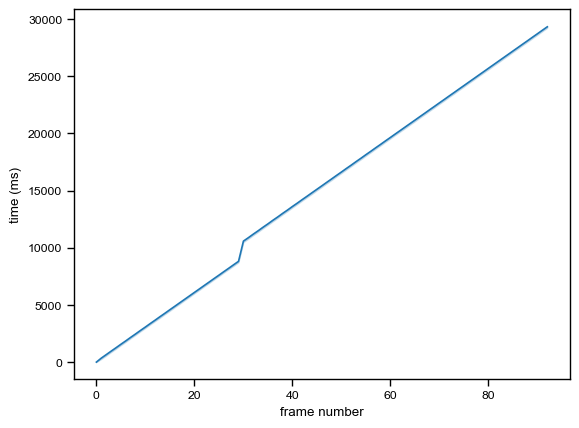

In [55]:
frames = mCherry_Data.FRAME.unique()

g = []
h = []

for f in frames:
    l =  mCherry_Data[mCherry_Data.FRAME == f].TIME.astype('float').tolist()
    g.extend(l)
    h.extend(np.tile(f,len(l)))

df = pd.DataFrame({'h' : h, 'g' : g})
sns.lineplot(df, x = h, y = g, errorbar=("pi", 100))

plt.xlabel('frame number')
plt.ylabel('time (ms)')

(0.0, 4000.0)

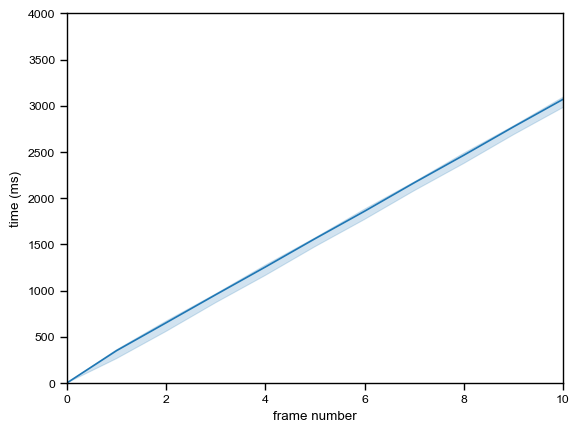

In [56]:
sns.lineplot(df, x = h, y = g, errorbar=("pi", 100))

plt.xlabel('frame number')
plt.ylabel('time (ms)')

plt.xlim(0,10)
plt.ylim(0,4000)

Text(0, 0.5, 'time (ms)')

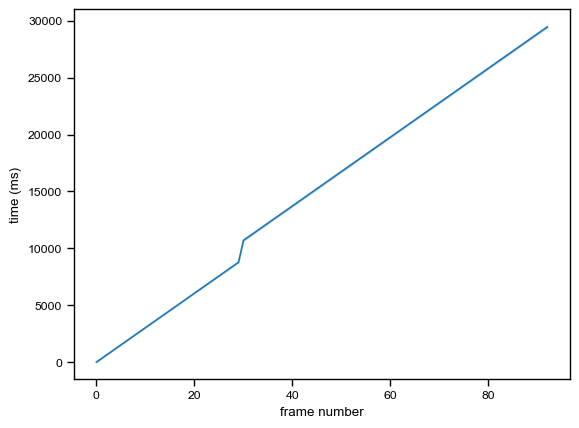

In [57]:
frames = mClover_Data.FRAME.unique()

g = []
h = []

for f in frames:
    l = mClover_Data[mClover_Data.FRAME == f].TIME.astype('float').tolist()
    g.extend(l)
    h.extend(np.tile(f,len(l)))

df = pd.DataFrame({'h' : h, 'g' : g})
sns.lineplot(df, x = h, y = g, errorbar=("pi", 100))

plt.xlabel('frame number')
plt.ylabel('time (ms)')

## normalise FRAP traces to unbleached control region and to fixed FRAP traces

In [58]:
frames = mClover_Data.FRAME.unique()
mean_time = []

for f in frames:
    avg = mClover_Data[mClover_Data.FRAME == f].TIME.astype('float').mean()
    mean_time.append(avg)

filename = []
baseline_intensity = []
date = []
condition = []
celltype = []
timer = []
intensities = []


for each in mClover_Data.FILE.unique():
    
    crop = mClover_Data[mClover_Data.FILE == each]
        
    raw = crop[crop.BLEACH == 'Bleached'].INTENSITY
    baseline = np.mean(raw[:30])
    
    ints = crop[crop.BLEACH == 'Bleached'].INTENSITY_PCT
    hunds = crop[crop.BLEACH == 'Control'].INTENSITY_PCT
    
    cond = mClover_Data[mClover_Data.FILE == each].CONDITION.unique()[0]
    cell = mClover_Data[mClover_Data.FILE == each].CELL.unique()[0]
    
    zero_val = mClover_Fixed_ZeroValues[mClover_Fixed_ZeroValues.index == cell].iloc[0]
    
    ints_zerod = [i - zero_val for i in ints]
    hunds_zerod = [i - zero_val for i in hunds]
    
    ints_norm = [100*(i/h) for i,h in zip(ints_zerod, hunds_zerod)]
    
    lngth = len(ints_norm)
    
    filename.extend(np.tile(each,lngth))
    baseline_intensity.extend(np.tile(baseline,lngth))
    date.extend((np.tile(each[:6],lngth)))
    condition.extend(np.tile(cond,lngth))
    celltype.extend(np.tile(cell,lngth))
    intensities.extend(ints_norm)
    timer.extend(mean_time[:lngth])
    
    
mClover_Normalised_Data = pd.DataFrame({
"FILE" : filename,
"DATE" : date,
"CELL" : celltype,
"CONDITION" : condition,
"TIME" : timer,
"INTENSITY_NORMED" : intensities,
"BASELINE_INTENSITY" : baseline_intensity})

In [59]:
frames = mCherry_Data.FRAME.unique()
mean_time = []

for f in frames:
    avg = mCherry_Data[mCherry_Data.FRAME == f].TIME.astype('float').mean()
    mean_time.append(avg)

filename = []
date = []
condition = []
celltype = []
timer = []
intensities = []
baseline_intensity = []

for each in mCherry_Data.FILE.unique():
    
    crop = mCherry_Data[mCherry_Data.FILE == each]
    
    raw = crop[crop.BLEACH == 'Bleached'].INTENSITY
    baseline = np.mean(raw[:30])
    
    ints = crop[crop.BLEACH == 'Bleached'].INTENSITY_PCT
    hunds = crop[crop.BLEACH == 'Control'].INTENSITY_PCT
    
    cond = mCherry_Data[mCherry_Data.FILE == each].CONDITION.unique()[0]
    cell = mCherry_Data[mCherry_Data.FILE == each].CELL.unique()[0]
    day = mCherry_Data[mCherry_Data.FILE == each].DATE.unique()[0]
    
    zero_val = mCherry_Fixed_ZeroValues[mCherry_Fixed_ZeroValues.index == cell].iloc[0]
    
    ints_zerod = [i - zero_val for i in ints]
    hunds_zerod = [i - zero_val for i in hunds]
    
    ints_norm = [100*(i/h) for i,h in zip(ints_zerod, hunds_zerod)]
    
    lngth = len(ints_norm)
    
    filename.extend(np.tile(each,lngth))
    baseline_intensity.extend(np.tile(baseline,lngth))
    date.extend((np.tile(each[:6],lngth)))
    condition.extend(np.tile(cond,lngth))
    celltype.extend(np.tile(cell,lngth))
    intensities.extend(ints_norm)
    timer.extend(mean_time[:lngth])

mCherry_Normalised_Data = pd.DataFrame({
"FILE" : filename,
"DATE" : date,
"CELL" : celltype,
"CONDITION" : condition,
"TIME" : timer,
"INTENSITY_NORMED" : intensities,
"BASELINE_INTENSITY" : baseline_intensity})

## plot normalised FRAP traces across days, and per experimental day

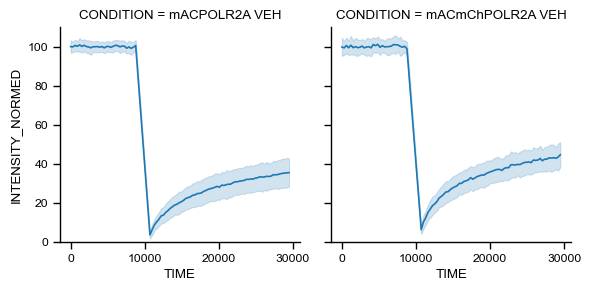

In [60]:
g = sns.FacetGrid(mClover_Normalised_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'TIME', y = 'INTENSITY_NORMED', errorbar = 'sd')

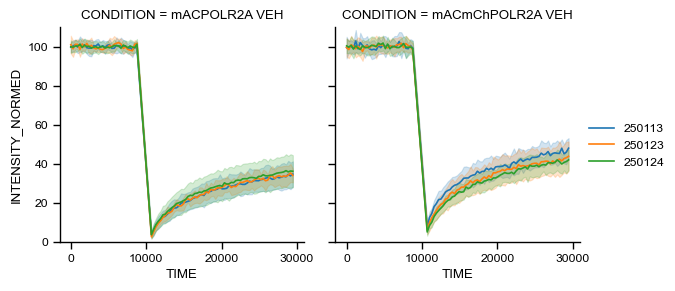

In [61]:
g = sns.FacetGrid(mClover_Normalised_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'TIME', y = 'INTENSITY_NORMED', hue = 'DATE', errorbar = 'sd')

g.add_legend()

<Axes: xlabel='TIME', ylabel='INTENSITY_NORMED'>

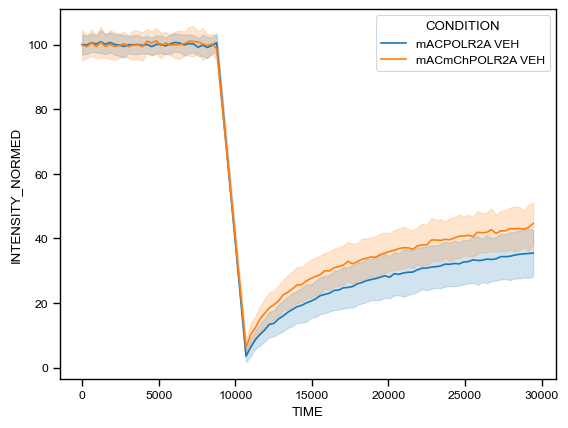

In [62]:
sns.lineplot(mClover_Normalised_Data, x = 'TIME', y = 'INTENSITY_NORMED', hue = 'CONDITION', errorbar = 'sd')

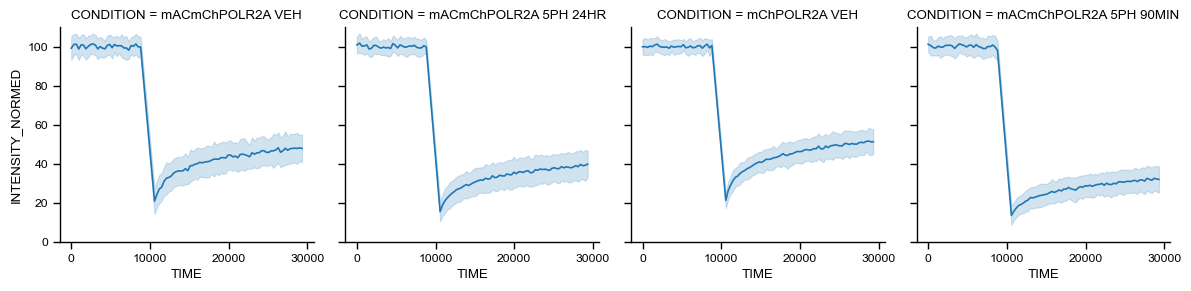

In [63]:
g = sns.FacetGrid(mCherry_Normalised_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'TIME', y = 'INTENSITY_NORMED', errorbar = 'sd')

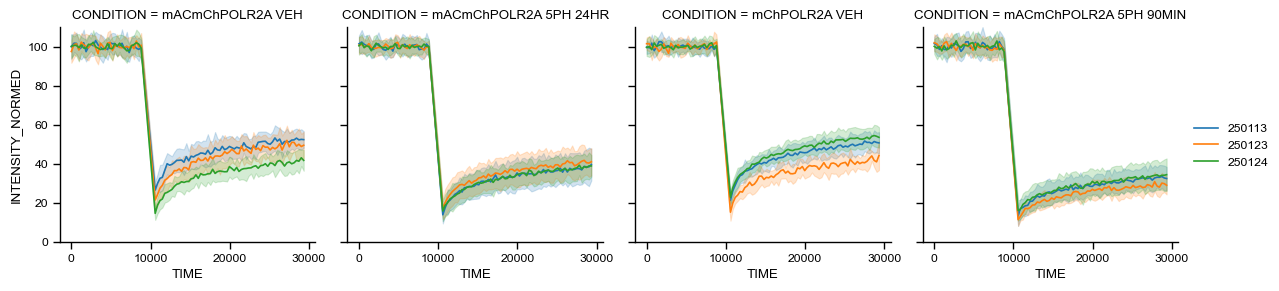

In [64]:
g = sns.FacetGrid(mCherry_Normalised_Data, col = 'CONDITION', ylim = (0,110))

g.map_dataframe(sns.lineplot, x = 'TIME', y = 'INTENSITY_NORMED', hue = 'DATE', errorbar = 'sd')

g.add_legend()

(0.0, 110.0)

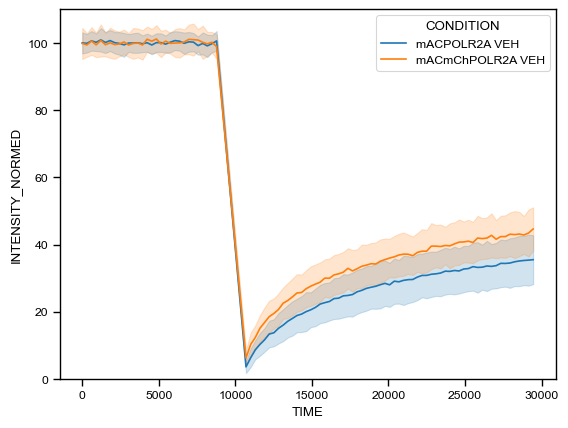

In [65]:
sns.lineplot(mClover_Normalised_Data, 
             hue = 'CONDITION', 
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
            errorbar = 'sd')

plt.ylim(0,110)

In [66]:
mCherry_Normalised_Data.CONDITION.unique().tolist()

['mACmChPOLR2A VEH',
 'mACmChPOLR2A 5PH 24HR',
 'mChPOLR2A VEH',
 'mACmChPOLR2A 5PH 90MIN']

(0.0, 110.0)

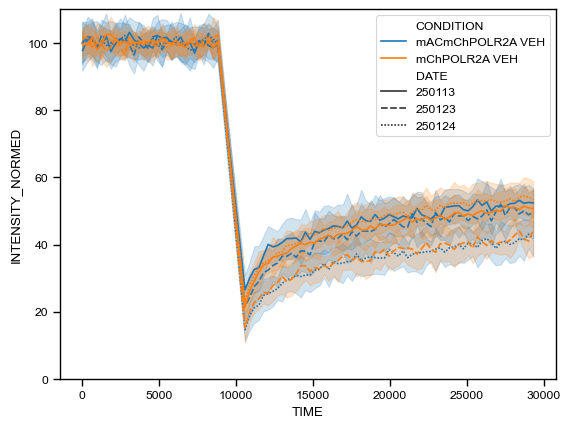

In [67]:
sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mChPOLR2A VEH"'), 
             hue = 'CONDITION', 
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
             style = 'DATE',
            errorbar = 'sd')

plt.ylim(0,110)

(0.0, 110.0)

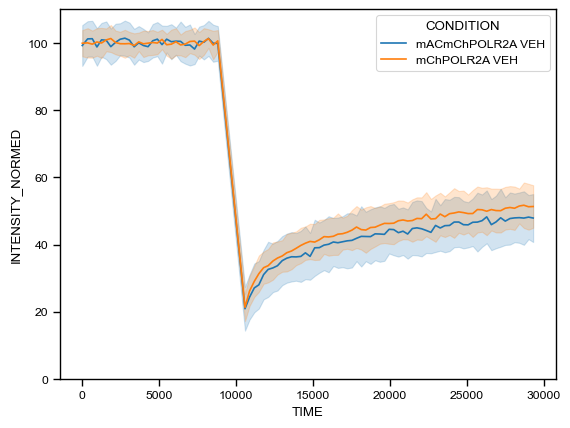

In [68]:
sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mChPOLR2A VEH"'), 
             hue = 'CONDITION', 
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
            errorbar = 'sd')

plt.ylim(0,110)

(0.0, 120.0)

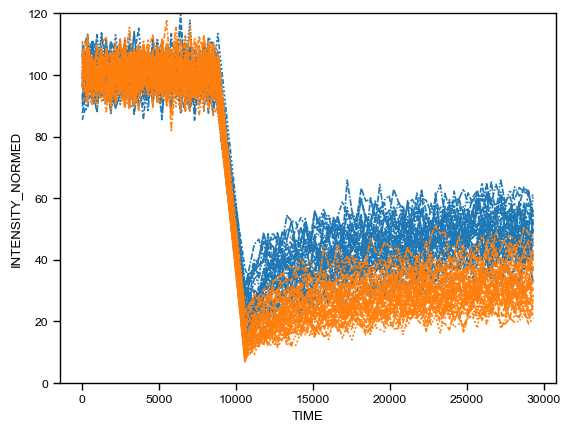

In [69]:
sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
             hue = 'CONDITION', 
             style = 'FILE',
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
            errorbar = 'sd', legend = False)

plt.ylim(0,120)

(0.0, 110.0)

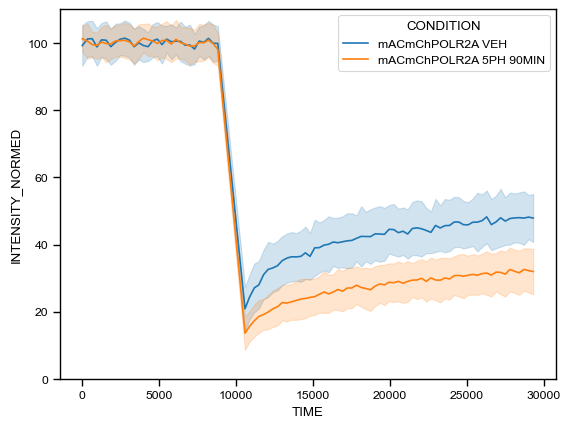

In [70]:
sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
             hue = 'CONDITION', 
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
            errorbar = 'sd')

plt.ylim(0,110)

(0.0, 110.0)

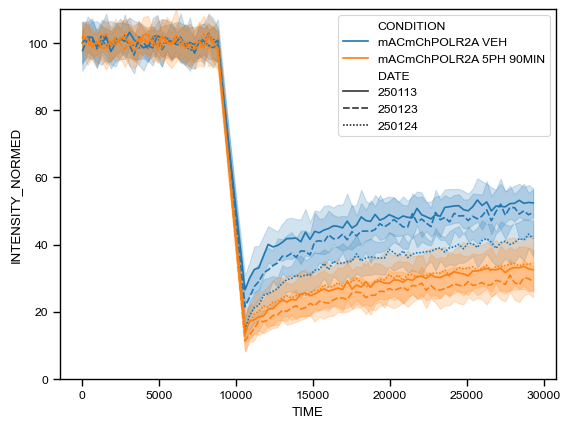

In [71]:
sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
             hue = 'CONDITION',
             style = 'DATE',
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
            errorbar = 'sd')

plt.ylim(0,110)

(0.0, 110.0)

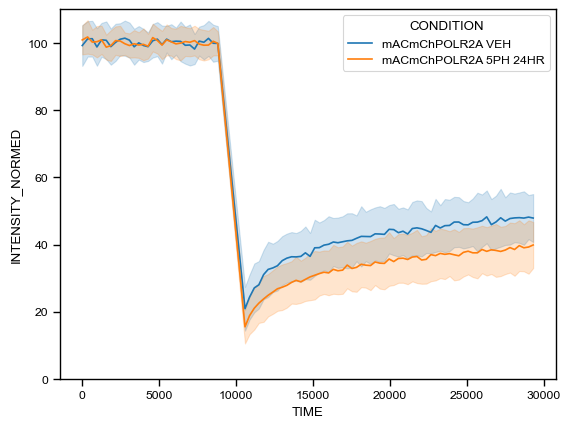

In [72]:
sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 24HR"'), 
             hue = 'CONDITION', 
             x = 'TIME', 
             y = 'INTENSITY_NORMED',
            errorbar = 'sd')

plt.ylim(0,110)

## compare intensity value at last timepoint to check recovery after photobleaching without fitting

### for mcherry

In [73]:
lasttime = mCherry_Normalised_Data.TIME.max()
RecoveredValuemCherry = mCherry_Normalised_Data[mCherry_Normalised_Data['TIME'] == lasttime]

In [74]:
RecoveredValuemCherry.CONDITION.unique()

array(['mACmChPOLR2A VEH', 'mACmChPOLR2A 5PH 24HR', 'mChPOLR2A VEH',
       'mACmChPOLR2A 5PH 90MIN'], dtype=object)

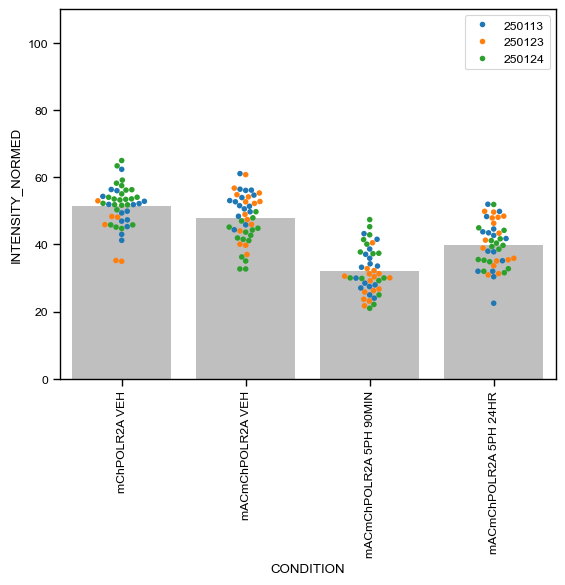

In [75]:
sns.swarmplot(RecoveredValuemCherry, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'INTENSITY_NORMED', 
              hue = 'DATE', 
              size = 4)
sns.barplot(RecoveredValuemCherry, 
            x = 'CONDITION', 
            y = 'INTENSITY_NORMED', 
            alpha = 0.25, 
            color = 'black', 
            errorbar = None)

plt.ylim(0,110);
plt.xticks(rotation = 90);

In [76]:
RecoveredValuemCherryByDay = RecoveredValuemCherry.drop(['FILE','CELL','TIME'], axis = 1).groupby(['DATE', 'CONDITION']).mean().reset_index()

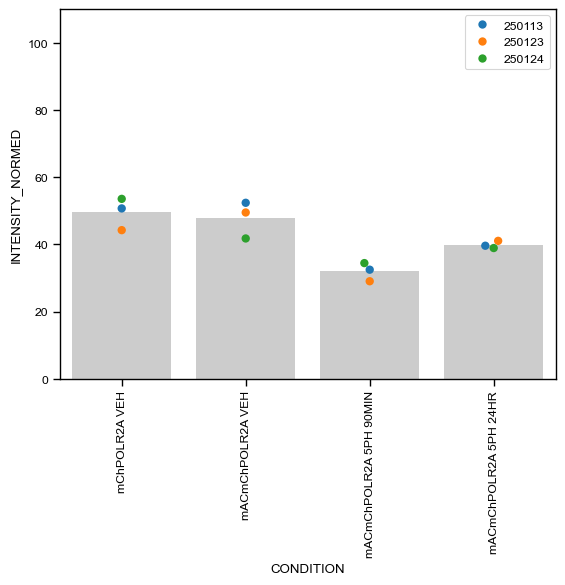

In [77]:
sns.swarmplot(RecoveredValuemCherryByDay, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'INTENSITY_NORMED', 
              size = 6, hue = 'DATE')
sns.barplot(RecoveredValuemCherryByDay, x = 'CONDITION', y = 'INTENSITY_NORMED', alpha = 0.2, color = 'black', errorbar = None)

plt.ylim(0,110);
plt.xticks(rotation = 90);

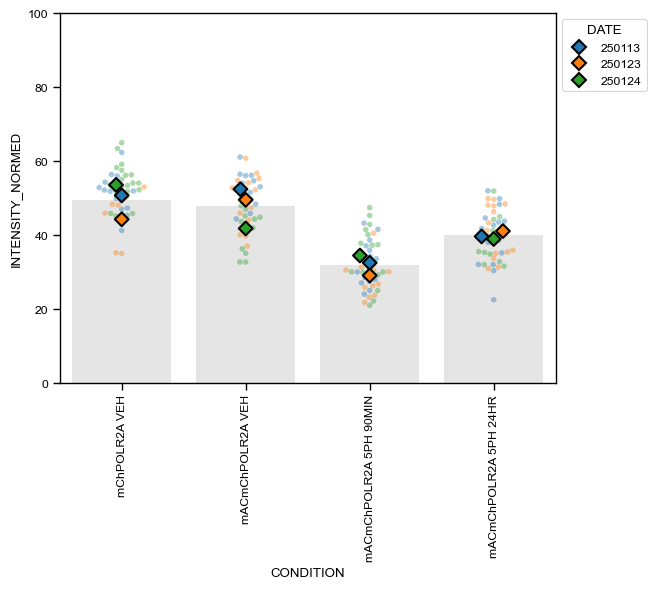

In [78]:
sns.barplot(RecoveredValuemCherryByDay, 
            x = 'CONDITION', 
            order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
            y = 'INTENSITY_NORMED', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(RecoveredValuemCherry, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'INTENSITY_NORMED', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(RecoveredValuemCherryByDay, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'INTENSITY_NORMED',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,100)
plt.xticks(rotation = 90);

In [79]:
RecoveredValuemCherry.drop(['FILE','CELL','TIME','DATE'], axis = 1).groupby(['CONDITION']).mean().reset_index()

,CONDITION,INTENSITY_NORMED,BASELINE_INTENSITY
0,mACmChPOLR2A 5PH 24HR,39.856395,31.609798
1,mACmChPOLR2A 5PH 90MIN,31.978659,22.791792
2,mACmChPOLR2A VEH,47.880434,20.503491
3,mChPOLR2A VEH,51.311215,37.917983


### for mclover

In [80]:
lasttime = mClover_Normalised_Data.TIME.max()

In [81]:
RecoveredValuemClover = mClover_Normalised_Data[mClover_Normalised_Data['TIME'] == lasttime]
RecoveredValuemCloverByDay = RecoveredValuemClover.drop(['FILE','CELL','TIME'], axis = 1).groupby(['DATE', 'CONDITION']).mean().reset_index()

In [82]:
RecoveredValuemClover.CONDITION.unique()

array(['mACPOLR2A VEH', 'mACmChPOLR2A VEH'], dtype=object)

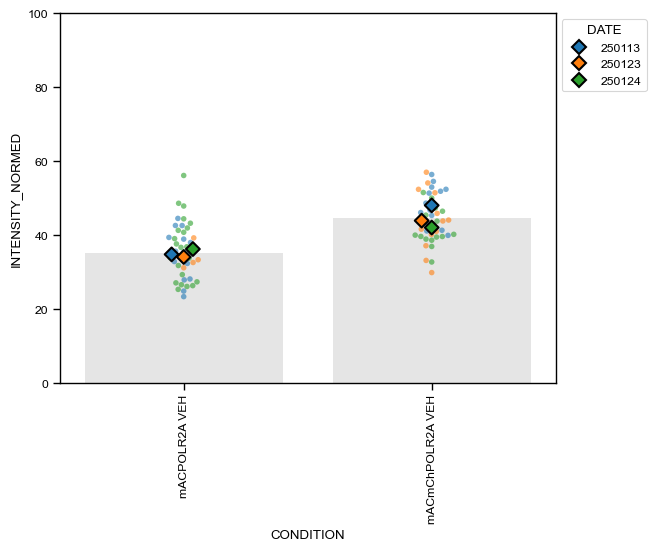

In [83]:
sns.barplot(RecoveredValuemCloverByDay, 
            x = 'CONDITION', 
            order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
            y = 'INTENSITY_NORMED', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(RecoveredValuemClover, 
              x = 'CONDITION', 
              order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
              y = 'INTENSITY_NORMED', 
              hue = 'DATE', 
              size = 4, alpha = 0.6,
                 legend = False)

h = sns.swarmplot(RecoveredValuemCloverByDay, 
              x = 'CONDITION', 
              order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
              y = 'INTENSITY_NORMED',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,100)
plt.xticks(rotation = 90);

In [84]:
RecoveredValuemClover.drop(['FILE','CELL','TIME','DATE'], axis = 1).groupby(['CONDITION']).mean().reset_index()

,CONDITION,INTENSITY_NORMED,BASELINE_INTENSITY
0,mACPOLR2A VEH,35.484975,24.306346
1,mACmChPOLR2A VEH,44.627794,12.739839


In [85]:
RecoveredValuemClover.drop(['FILE','CELL','TIME','DATE'], axis = 1).groupby(['CONDITION']).std().reset_index()

,CONDITION,INTENSITY_NORMED,BASELINE_INTENSITY
0,mACPOLR2A VEH,7.271443,4.116439
1,mACmChPOLR2A VEH,6.446865,2.303106


## fitting FRAP data to single exponential recovery curve

In [86]:
def MonoEx(x, A, B):
    return A * (1- np.exp(-B * x))

### for mcherry

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00

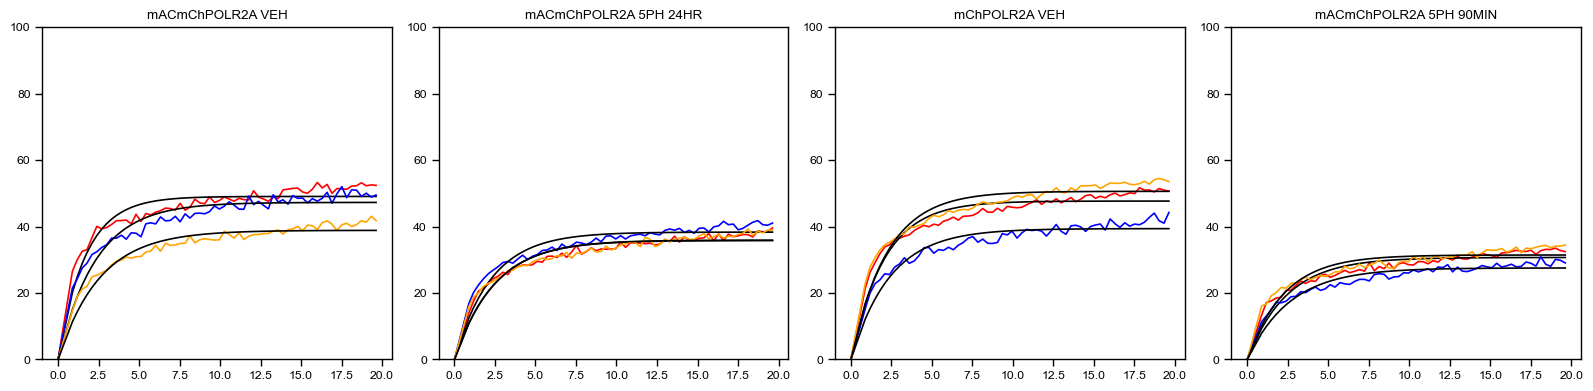

In [87]:
f , a = plt.subplots(ncols = 4, figsize = (16,4))

colours = ['red', 'blue', 'orange']


for col,c in enumerate(mCherry_Normalised_Data.CONDITION.unique()):
    for h,d in enumerate(mCherry_Normalised_Data.DATE.unique()):
        
        frame = mCherry_Normalised_Data[
            (mCherry_Normalised_Data['CONDITION'] == c) & (mCherry_Normalised_Data['DATE'] == d)].drop(['CONDITION','FILE','DATE','CELL'], axis = 1)
        
        frame = frame.groupby('TIME').mean().reset_index()
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        sns.lineplot(x = xs, y = ys, ax = a[col], color = colours[h])
        sns.lineplot(x = xs, y = [MonoEx(i, plat, tau) for i in xs], ax = a[col], color = 'black')
        a[col].set_ylim(0,100)
        a[col].set_title(c)
        
plt.tight_layout()

In [88]:
conditions = []
dates = []
taus = []
plats = []
baselines = []

for c in mCherry_Normalised_Data.CONDITION.unique():
    for d in mCherry_Normalised_Data.DATE.unique():
        
        frame = mCherry_Normalised_Data[
            (mCherry_Normalised_Data['CONDITION'] == c) & (mCherry_Normalised_Data['DATE'] == d)].drop(['CONDITION','FILE','DATE','CELL'], axis = 1)
        
        frame = frame.groupby('TIME').mean().reset_index()
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        bl = frame.BASELINE_INTENSITY.unique()[0]
        
        conditions.append(c)
        dates.append(d)
        taus.append(tau)
        plats.append(plat)
        baselines.append(bl)
        
mCherryFittingPerDay = pd.DataFrame({
    'CONDITION' : conditions,
    'DATE' : dates,
    'TAU' : taus,
    'PLATEAU' : plats,
    'BASELINE_INTENSITY' : baselines})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00

In [89]:
files = []
conditions = []
dates = []
taus = []
plats = []
baseline_intensity = []

for f in mCherry_Normalised_Data.FILE.unique():
        
        frame = mCherry_Normalised_Data[(mCherry_Normalised_Data['FILE'] == f)]
        
        c = frame.CONDITION.unique()[0]
        d = frame.DATE.unique()[0]
        bl = frame.BASELINE_INTENSITY.unique()[0]
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        files.append(f)
        conditions.append(c)
        dates.append(d)
        taus.append(tau)
        plats.append(plat)
        baseline_intensity.append(bl)
        
mCherryFittingPerCell = pd.DataFrame({
    'FILE' : files,
    'CONDITION' : conditions,
    'DATE' : dates,
    'TAU' : taus,
    'PLATEAU' : plats,
    'BASELINE_INTENSITY' : baseline_intensity})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))


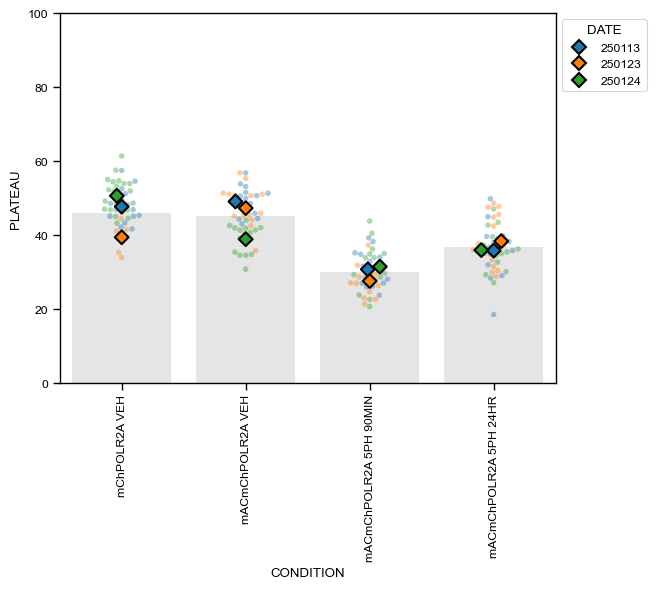

In [90]:
sns.barplot(mCherryFittingPerDay, 
            x = 'CONDITION', 
            order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
            y = 'PLATEAU', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(mCherryFittingPerCell, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'PLATEAU', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(mCherryFittingPerDay, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'PLATEAU',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,100)
plt.xticks(rotation = 90);

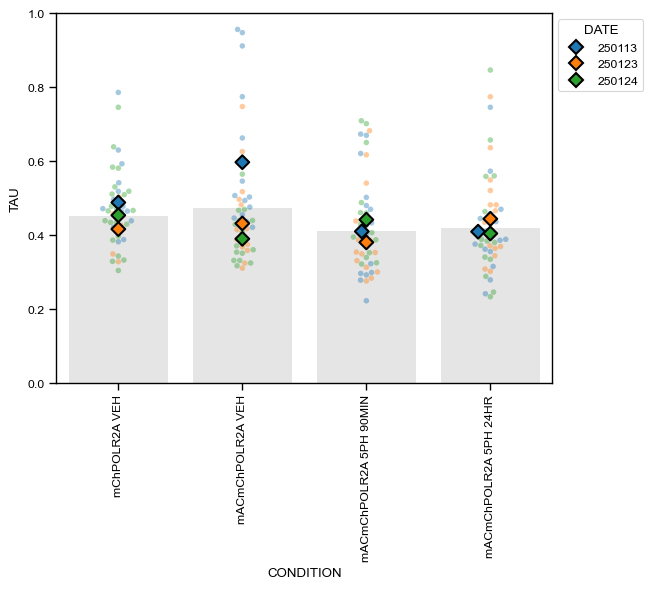

In [91]:
sns.barplot(mCherryFittingPerDay, 
            x = 'CONDITION', 
            order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
            y = 'TAU', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(mCherryFittingPerCell, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'TAU', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(mCherryFittingPerDay, 
              x = 'CONDITION', 
              order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
              y = 'TAU',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,1)
plt.xticks(rotation = 90);

In [92]:
mCherryFittingPerDay.drop('DATE',axis = 1).groupby('CONDITION').mean()

,TAU,PLATEAU,BASELINE_INTENSITY
CONDITION,,,
mACmChPOLR2A 5PH 24HR,0.418807,36.669786,31.609798
mACmChPOLR2A 5PH 90MIN,0.410284,29.888885,22.791792
mACmChPOLR2A VEH,0.472521,45.057298,20.503491
mChPOLR2A VEH,0.452314,45.878908,37.665343


In [93]:
mCherryFittingPerDay.drop('DATE',axis = 1).groupby('CONDITION').std()

,TAU,PLATEAU,BASELINE_INTENSITY
CONDITION,,,
mACmChPOLR2A 5PH 24HR,0.021573,1.432981,1.003054
mACmChPOLR2A 5PH 90MIN,0.030731,2.069357,1.532127
mACmChPOLR2A VEH,0.109653,5.445246,2.401920
mChPOLR2A VEH,0.036044,5.820101,1.789089


### for mclover

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00

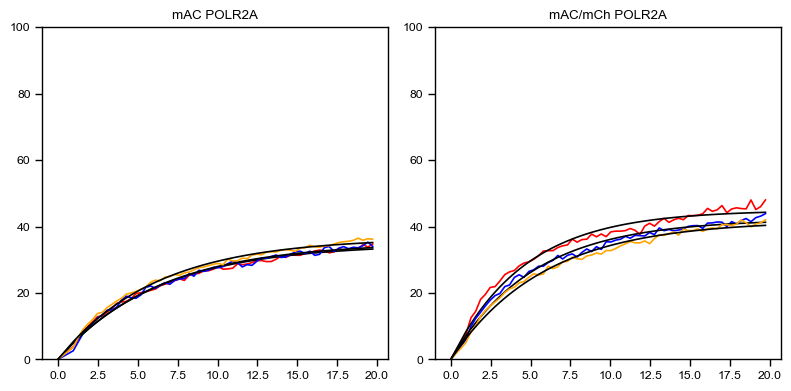

In [94]:
f , a = plt.subplots(ncols = 2, figsize = (8,4))


a[0].set_title('mAC POLR2A')
a[1].set_title('mAC/mCh POLR2A')

colours = ['red', 'blue', 'orange']

for col,c in enumerate(mClover_Normalised_Data.CONDITION.unique()):
    for h,d in enumerate(mClover_Normalised_Data.DATE.unique()):
        
        frame = mClover_Normalised_Data[
            (mClover_Normalised_Data['CONDITION'] == c) & (mClover_Normalised_Data['DATE'] == d)].drop(['CONDITION','FILE','DATE','CELL'], axis = 1)
        
        frame = frame.groupby('TIME').mean().reset_index()
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        sns.lineplot(x = xs, y = ys, ax = a[col], color = colours[h])
        sns.lineplot(x = xs, y = [MonoEx(i, plat, tau) for i in xs], ax = a[col], color = 'black')
        a[col].set_ylim(0,100)
        
plt.tight_layout()

In [95]:
conditions = []
dates = []
taus = []
plats = []
baselines = []

for c in mClover_Normalised_Data.CONDITION.unique():
    for d in mClover_Normalised_Data.DATE.unique():
        
        frame = mClover_Normalised_Data[
            (mClover_Normalised_Data['CONDITION'] == c) & (mClover_Normalised_Data['DATE'] == d)].drop(['CONDITION','FILE','DATE','CELL'], axis = 1)
        
        frame = frame.groupby('TIME').mean().reset_index()
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        bl = frame.BASELINE_INTENSITY.unique()[0]
        
        conditions.append(c)
        dates.append(d)
        taus.append(tau)
        plats.append(plat)
        baselines.append(bl)
        
mCloverFittingPerDay = pd.DataFrame({
    'CONDITION' : conditions,
    'DATE' : dates,
    'TAU' : taus,
    'PLATEAU' : plats,
    'BASELINE_INTENSITY' : baselines})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00

In [96]:
files = []
conditions = []
dates = []
taus = []
plats = []
baseline_intensity = []

for f in mClover_Normalised_Data.FILE.unique():
        
        frame = mClover_Normalised_Data[(mClover_Normalised_Data['FILE'] == f)]
        
        c = frame.CONDITION.unique()[0]
        d = frame.DATE.unique()[0]
        bl = frame.BASELINE_INTENSITY.unique()[0]
        
        xs = frame.TIME.tolist()
        ys = frame.INTENSITY_NORMED.tolist()
        
        zero_time =  xs[29] + (xs[30] - xs[29])/2
        
        xs = xs[30:]
        ys = ys[30:]

        xs = [(i-zero_time)/1000 for i in xs]

        xs = np.insert(xs,0,0)
        ys = np.insert(ys,0,0)
        
        popt, pcov = optimize.curve_fit(MonoEx, xs, ys, p0=[50, 5])
        plat = popt[0]
        tau = popt[1]
        
        files.append(f)
        conditions.append(c)
        dates.append(d)
        taus.append(tau)
        plats.append(plat)
        baseline_intensity.append(bl)
        
mCloverFittingPerCell = pd.DataFrame({
    'FILE' : files,
    'CONDITION' : conditions,
    'DATE' : dates,
    'TAU' : taus,
    'PLATEAU' : plats,
    'BASELINE_INTENSITY' : baseline_intensity})

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in exp
  return A * (1- np.exp(-B * x))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/3897103362.py:2: RuntimeWarning: overflow encountered in multiply
  return A * (1- np.exp(-B * x))


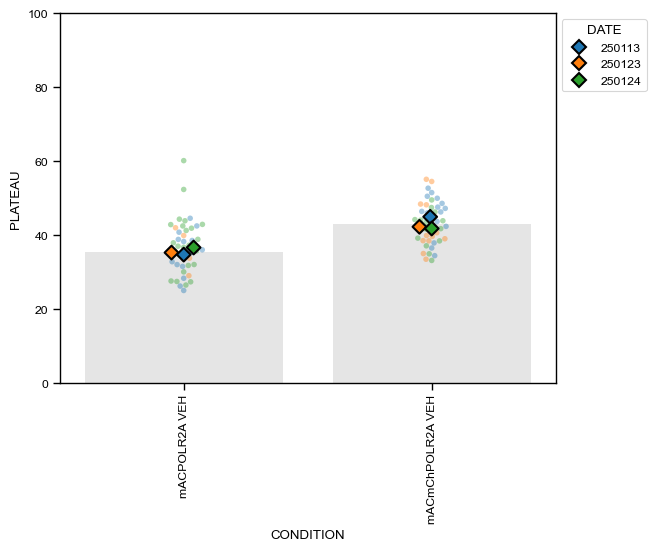

In [97]:
sns.barplot(mCloverFittingPerDay, 
            x = 'CONDITION', 
            order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
            y = 'PLATEAU', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(mCloverFittingPerCell, 
              x = 'CONDITION', 
              
              y = 'PLATEAU', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(mCloverFittingPerDay, 
              x = 'CONDITION', 
              
              y = 'PLATEAU',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,100)
plt.xticks(rotation = 90);

In [98]:
mCloverFittingPerDay

,CONDITION,DATE,TAU,PLATEAU,BASELINE_INTENSITY
0,mACPOLR2A VEH,250113,0.160419,34.682793,21.858599
1,mACPOLR2A VEH,250123,0.157826,35.230017,23.845813
2,mACPOLR2A VEH,250124,0.164793,36.599348,26.005241
3,mACmChPOLR2A VEH,250113,0.216112,44.911476,10.879158
4,mACmChPOLR2A VEH,250123,0.193766,42.209960,13.335120
5,mACmChPOLR2A VEH,250124,0.172432,41.741673,14.005237


In [99]:
mCloverFittingPerDay.drop('DATE', axis = 1).groupby('CONDITION').std()

,TAU,PLATEAU,BASELINE_INTENSITY
CONDITION,,,
mACPOLR2A VEH,0.003521,0.987227,2.073917
mACmChPOLR2A VEH,0.021842,1.711000,1.645862


In [100]:
mCloverFittingPerDay.drop('DATE', axis = 1).groupby('CONDITION').mean()

,TAU,PLATEAU,BASELINE_INTENSITY
CONDITION,,,
mACPOLR2A VEH,0.161012,35.504053,23.903218
mACmChPOLR2A VEH,0.194103,42.954370,12.739839


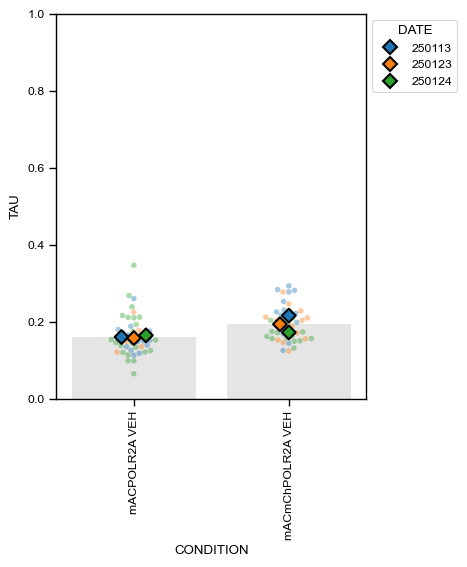

In [101]:
f,a = plt.subplots(figsize = (4,5))

sns.barplot(mCloverFittingPerDay, 
            x = 'CONDITION', 
            order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
            y = 'TAU', alpha = 0.1, color = 'black', errorbar = None)

i = sns.swarmplot(mCloverFittingPerCell, 
              x = 'CONDITION', 
              
              y = 'TAU', 
              hue = 'DATE', 
              size = 4, alpha = 0.4,
                 legend = False)

h = sns.swarmplot(mCloverFittingPerDay, 
              x = 'CONDITION', 
              
              y = 'TAU',
                  marker = 'D', edgecolor="black", linewidth = 1.5,
              size = 7, hue = 'DATE')



sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))
plt.ylim(0,1)
plt.xticks(rotation = 90);

## use baseline fluorescence intensity to calculate relative total Pol II amounts

### for mcherry

In [102]:
dates = []
conditions = []
amount_bound = []
amount_free = []
totals = []

for d in mCherryFittingPerDay.DATE.unique():
    crop = mCherryFittingPerDay[ mCherryFittingPerDay['DATE'] == d ]
    HundredPct = crop[ crop['CONDITION'] == 'mChPOLR2A VEH' ]['BASELINE_INTENSITY'].tolist()[0]
    
    for c in crop.CONDITION.unique():
        crop2 = crop[ crop['CONDITION'] == c ]
        
        relative_total = (crop2['BASELINE_INTENSITY'].tolist()[0]/HundredPct)
        plat = crop2['PLATEAU'].tolist()[0]
        
        free = (plat/100)*relative_total
        bound = relative_total - free
        
        dates.append(d)
        conditions.append(c)
        amount_bound.append(100*bound)
        amount_free.append(100*free)
        totals.append(100*relative_total)
        
mCherryPolAmountsPerDay = pd.DataFrame({
'DATE' :dates,
'CONDITION' :conditions,
'RELATIVE_TOTAL' : totals,
'BOUND' : amount_bound,
'FREE' : amount_free})

In [103]:
mCherryPolAmountsPerDay

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE
0,250113,mACmChPOLR2A VEH,49.638949,25.289301,24.349648
1,250113,mACmChPOLR2A 5PH 24HR,87.224964,56.015606,31.209359
2,250113,mChPOLR2A VEH,100.000000,52.336177,47.663823
3,250113,mACmChPOLR2A 5PH 90MIN,58.942836,40.851153,18.091683
4,250123,mACmChPOLR2A VEH,56.863899,29.988220,26.875680
5,250123,mACmChPOLR2A 5PH 24HR,86.410601,53.295593,33.115008
6,250123,mChPOLR2A VEH,100.000000,60.624622,39.375378
7,250123,mACmChPOLR2A 5PH 90MIN,63.433139,45.964890,17.468248
8,250124,mACmChPOLR2A VEH,56.459085,34.521786,21.937299
9,250124,mACmChPOLR2A 5PH 24HR,78.520999,50.327092,28.193907


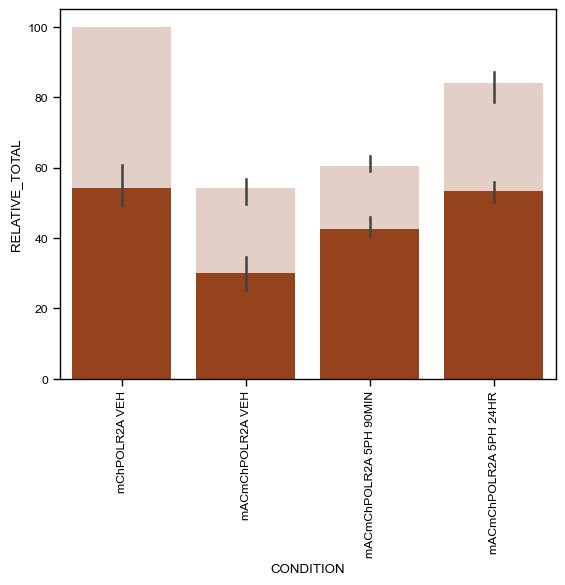

In [104]:
sns.barplot(mCherryPolAmountsPerDay, 
            x = 'CONDITION', 
            order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
            y = 'RELATIVE_TOTAL', 
            color = 'xkcd:rust', 
            alpha = 0.25,
           errorbar = ('pi',100))


sns.barplot(mCherryPolAmountsPerDay, x = 'CONDITION', color = 'xkcd:rust', y = 'BOUND')

plt.xticks(rotation = 90);

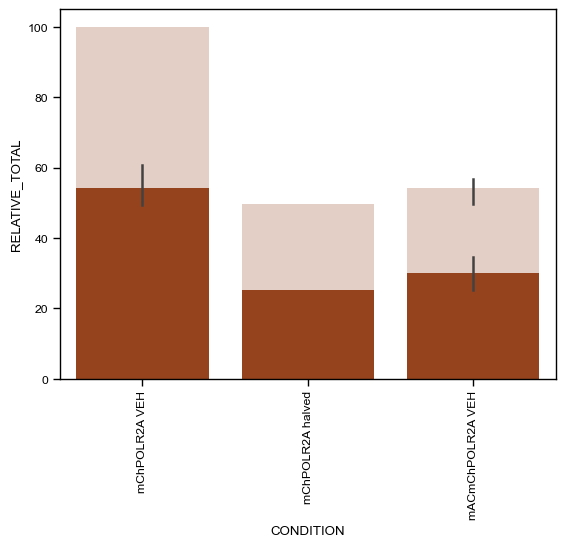

In [105]:
mCh_BOUNDAMOUNT_HALVED = mCherryPolAmountsPerDay.query('CONDITION == "mACPOLR2A VEH"').BOUND.mean() / 2
mCh_TOTALAMOUNT_HALVED = mCherryPolAmountsPerDay.query('CONDITION == "mACPOLR2A VEH"').RELATIVE_TOTAL.mean() / 2

cols = mCherryPolAmountsPerDay.columns.tolist()
newdata = [['NAD'], ['mChPOLR2A halved'], [mCh_TOTALAMOUNT_HALVED], [mCh_BOUNDAMOUNT_HALVED], [(mCh_TOTALAMOUNT_HALVED - mCh_BOUNDAMOUNT_HALVED)]]

newdf = pd.DataFrame(dict(zip(cols, newdata)))

newdf = pd.concat([mCherryPolAmountsPerDay.query('CONDITION == "mChPOLR2A VEH" | CONDITION == "mACmChPOLR2A VEH"'),newdf])

sns.barplot(newdf, 
            x = 'CONDITION', 
            order = ['mChPOLR2A VEH', 'mChPOLR2A halved', 'mACmChPOLR2A VEH'],
            y = 'RELATIVE_TOTAL', 
            color = 'xkcd:rust', 
            alpha = 0.25,
           errorbar = ('pi',100))

sns.barplot(newdf, x = 'CONDITION',
            order = ['mChPOLR2A VEH', 'mChPOLR2A halved', 'mACmChPOLR2A VEH'],
            y = 'BOUND',
            color = 'xkcd:rust',
           errorbar = ('pi',100))

plt.xticks(rotation = 90);

In [106]:
files = []
conditions = []
amount_bound = []
amount_free = []
totals = []

for f in mCherryFittingPerCell.FILE.unique():
    crop = mCherryFittingPerCell[ mCherryFittingPerCell['FILE'] == f ]
    
    c = crop.CONDITION.unique()[0]
    
    HundredPct = mCherryFittingPerCell[ mCherryFittingPerCell['CONDITION'] == 'mChPOLR2A VEH' ]['BASELINE_INTENSITY'].mean()

    relative_total = (crop['BASELINE_INTENSITY'].tolist()[0]/HundredPct)
    plat = crop['PLATEAU'].tolist()[0]

    free = (plat/100)*relative_total
    bound = relative_total - free

    files.append(f)
    conditions.append(c)
    amount_bound.append(100*bound)
    amount_free.append(100*free)
    totals.append(100*relative_total)
    
    
mCherryPolAmountsPerCell = pd.DataFrame({
'FILE' :files,
'CONDITION' :conditions,
'RELATIVE_TOTAL' : totals,
'BOUND' : amount_bound,
'FREE' : amount_free})

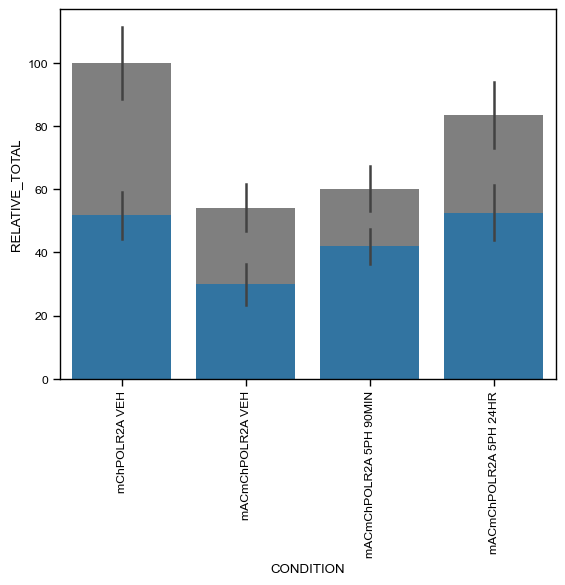

In [107]:
sns.barplot(mCherryPolAmountsPerCell, 
            x = 'CONDITION', 
            order = ['mChPOLR2A VEH', 'mACmChPOLR2A VEH',  'mACmChPOLR2A 5PH 90MIN', 'mACmChPOLR2A 5PH 24HR'],
            y = 'RELATIVE_TOTAL', 
            color = 'black', 
            alpha = 0.5,
           errorbar = 'sd')

sns.barplot(mCherryPolAmountsPerCell, x = 'CONDITION', y = 'BOUND', errorbar = 'sd')

plt.xticks(rotation = 90);

### for mclover

In [108]:
dates = []
conditions = []
amount_bound = []
amount_free = []
totals = []

for d in mCloverFittingPerDay.DATE.unique():
    crop = mCloverFittingPerDay[ mCloverFittingPerDay['DATE'] == d ]
    HundredPct = crop[ crop['CONDITION'] == 'mACPOLR2A VEH' ]['BASELINE_INTENSITY'].tolist()[0]
    
    for c in crop.CONDITION.unique():
        crop2 = crop[ crop['CONDITION'] == c ]
        
        relative_total = (crop2['BASELINE_INTENSITY'].tolist()[0]/HundredPct)
        plat = crop2['PLATEAU'].tolist()[0]
        
        free = (plat/100)*relative_total
        bound = relative_total - free
        
        dates.append(d)
        conditions.append(c)
        amount_bound.append(100*bound)
        amount_free.append(100*free)
        totals.append(100*relative_total)
        
mCloverPolAmountsPerDay = pd.DataFrame({
'DATE' :dates,
'CONDITION' :conditions,
'RELATIVE_TOTAL' : totals,
'BOUND' : amount_bound,
'FREE' : amount_free})

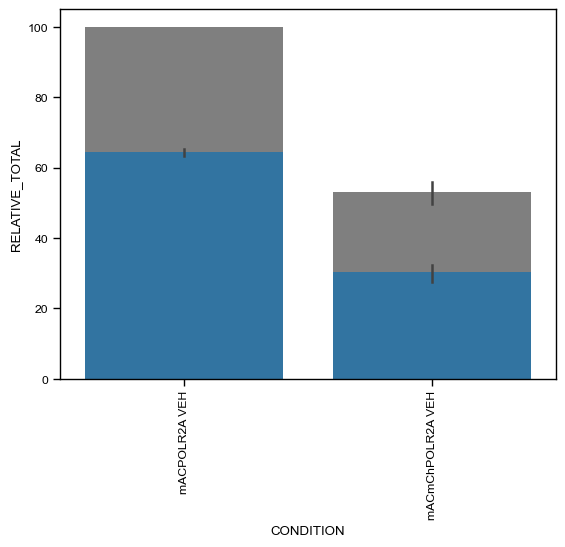

In [109]:
sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION', 
            order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
            y = 'RELATIVE_TOTAL', 
            color = 'black', 
            alpha = 0.5,
           errorbar = ('pi',100))

sns.barplot(mCloverPolAmountsPerDay, x = 'CONDITION', y = 'BOUND',
           errorbar = ('pi',100))

plt.xticks(rotation = 90);

In [110]:
mCloverPolAmountsPerDay

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE
0,250113,mACPOLR2A VEH,100.000000,65.317207,34.682793
1,250113,mACmChPOLR2A VEH,49.770611,27.417895,22.352716
2,250123,mACPOLR2A VEH,100.000000,64.769983,35.230017
3,250123,mACmChPOLR2A VEH,55.922269,32.317502,23.604768
4,250124,mACPOLR2A VEH,100.000000,63.400652,36.599348
5,250124,mACmChPOLR2A VEH,53.855441,31.375279,22.480162


In [111]:
newdf

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE
0,250113,mACmChPOLR2A VEH,49.638949,25.289301,24.349648
2,250113,mChPOLR2A VEH,100.000000,52.336177,47.663823
4,250123,mACmChPOLR2A VEH,56.863899,29.988220,26.875680
6,250123,mChPOLR2A VEH,100.000000,60.624622,39.375378
8,250124,mACmChPOLR2A VEH,56.459085,34.521786,21.937299
10,250124,mChPOLR2A VEH,100.000000,49.402477,50.597523
0,NAD,mChPOLR2A halved,NaN,NaN,NaN


In [112]:
newdf

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE
0,250113,mACmChPOLR2A VEH,49.638949,25.289301,24.349648
2,250113,mChPOLR2A VEH,100.000000,52.336177,47.663823
4,250123,mACmChPOLR2A VEH,56.863899,29.988220,26.875680
6,250123,mChPOLR2A VEH,100.000000,60.624622,39.375378
8,250124,mACmChPOLR2A VEH,56.459085,34.521786,21.937299
10,250124,mChPOLR2A VEH,100.000000,49.402477,50.597523
0,NAD,mChPOLR2A halved,NaN,NaN,NaN


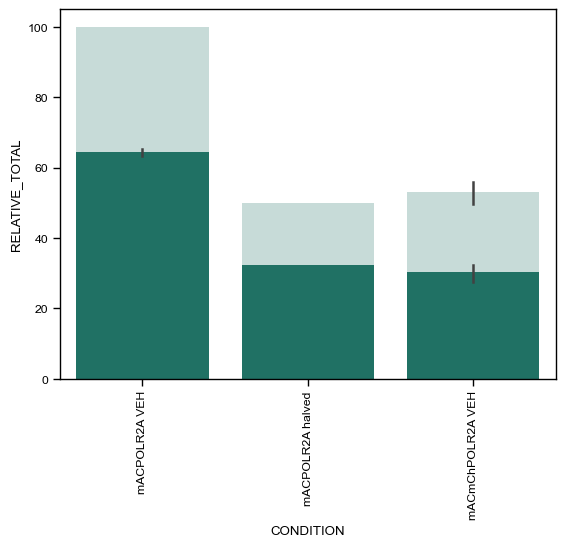

In [113]:
mAC_BOUNDAMOUNT_HALVED = mCloverPolAmountsPerDay.query('CONDITION == "mACPOLR2A VEH"').BOUND.mean() / 2
mAC_TOTALAMOUNT_HALVED = mCloverPolAmountsPerDay.query('CONDITION == "mACPOLR2A VEH"').RELATIVE_TOTAL.mean() / 2

cols = mCloverPolAmountsPerDay.columns.tolist()
newdata = [['NAD'], ['mACPOLR2A halved'], [mAC_TOTALAMOUNT_HALVED], [mAC_BOUNDAMOUNT_HALVED], [(mAC_TOTALAMOUNT_HALVED - mAC_BOUNDAMOUNT_HALVED)]]

newdf = pd.DataFrame(dict(zip(cols, newdata)))

newdf = pd.concat([mCloverPolAmountsPerDay,newdf])

sns.barplot(newdf, 
            x = 'CONDITION', 
            order = ['mACPOLR2A VEH', 'mACPOLR2A halved', 'mACmChPOLR2A VEH'],
            y = 'RELATIVE_TOTAL', 
            color = 'xkcd:blue green', 
            alpha = 0.25,
           errorbar = ('pi',100))

sns.barplot(newdf, x = 'CONDITION',
            order = ['mACPOLR2A VEH', 'mACPOLR2A halved', 'mACmChPOLR2A VEH'],
            y = 'BOUND',
            color = 'xkcd:blue green',
           errorbar = ('pi',100))

plt.xticks(rotation = 90);

In [114]:
files = []
conditions = []
amount_bound = []
amount_free = []
totals = []

for f in mCloverFittingPerCell.FILE.unique():
    crop = mCloverFittingPerCell[ mCloverFittingPerCell['FILE'] == f ]
    
    c = crop.CONDITION.unique()[0]
    
    HundredPct = mCloverFittingPerCell[ mCloverFittingPerCell['CONDITION'] == 'mACPOLR2A VEH' ]['BASELINE_INTENSITY'].mean()

    relative_total = (crop['BASELINE_INTENSITY'].tolist()[0]/HundredPct)
    plat = crop['PLATEAU'].tolist()[0]

    free = (plat/100)*relative_total
    bound = relative_total - free

    files.append(f)
    conditions.append(c)
    amount_bound.append(100*bound)
    amount_free.append(100*free)
    totals.append(100*relative_total)
    
    
mCloverPolAmountsPerCell = pd.DataFrame({
'FILE' :files,
'CONDITION' :conditions,
'RELATIVE_TOTAL' : totals,
'BOUND' : amount_bound,
'FREE' : amount_free})

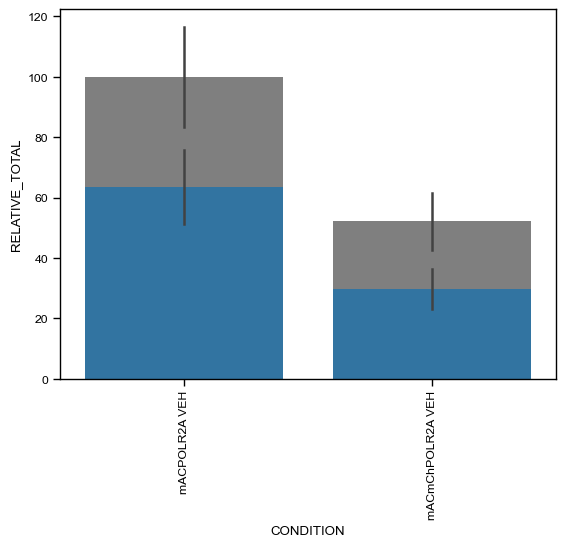

In [115]:
sns.barplot(mCloverPolAmountsPerCell, 
            x = 'CONDITION', 
            order = ['mACPOLR2A VEH', 'mACmChPOLR2A VEH'],
            y = 'RELATIVE_TOTAL', 
            color = 'black', 
            alpha = 0.5,
           errorbar = 'sd')
sns.barplot(mCloverPolAmountsPerCell, x = 'CONDITION', y = 'BOUND', errorbar = 'sd')

plt.xticks(rotation = 90);

## an example image

In [116]:
SNAPmAC = AICSImage("250113_mACmChPOLR2A_FRAP/WELL01_mACPOLR2A_VEH_24HR_GREEN/WELL01_GREENFRAP_CELL03_RED_GREEN_SNAP.czi").get_image_data('CYX')
SNAPmCh = AICSImage("250113_mACmChPOLR2A_FRAP/WELL06_mChPOLR2A_VEH_90MIN_RED/WELL06_REDFRAP_CELL03_RED_GREEN_SNAP.czi").get_image_data('CYX')
SNAP = AICSImage("250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_VEH_24HR_RED/WELL03_REDFRAP_CELL04_RED_GREEN_SNAP.czi").get_image_data('CYX')

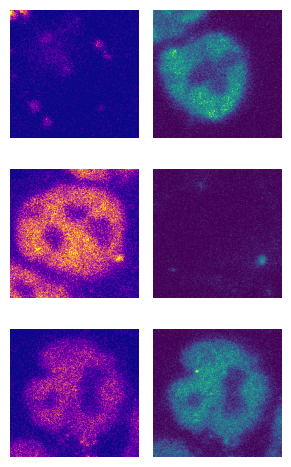

In [117]:
f, a = plt.subplots( ncols = 2, nrows = 3, figsize = (3,5))

vm = [60,40]
maps = ['plasma','viridis']

for i in [0,1]:
    a[0,i].imshow(SNAPmAC[i], vmax = vm[i], cmap = maps[i])
    a[1,i].imshow(SNAPmCh[i], vmax = vm[i], cmap = maps[i])
    a[2,i].imshow(SNAP[i], vmax = vm[i], cmap = maps[i])
    
    for j in range(3):
        a[j,i].axis('off')
    
plt.tight_layout()
plt.savefig('FRAP_egs.png')

In [118]:
FRAP_TRACE = pd.read_csv("250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_VEH_24HR_RED/WELL03_REDFRAP_CELL04_FRAP.csv")

In [119]:
FRAP_TRACE.columns.tolist()

['Time::Relative Time!!R',
 'Markers::Markers',
 'Channel1_R1_Area::mCher_R1_Area!!R',
 'Channel1_R1_IntensityAreaThrs::mCher_R1_IntensityAreaThrs!!R',
 'Channel1_R1_IntensityMean::mCher_R1_IntensityMean!!R',
 'Channel1_R1_IntensityMeanThrs::mCher_R1_IntensityMeanThrs!!R',
 'Channel1_R2_Area::mCher_R2_Area!!R',
 'Channel1_R2_IntensityAreaThrs::mCher_R2_IntensityAreaThrs!!R',
 'Channel1_R2_IntensityMean::mCher_R2_IntensityMean!!R',
 'Channel1_R2_IntensityMeanThrs::mCher_R2_IntensityMeanThrs!!R',
 'Ratio_R1::Ratio_R1!!R',
 'Ratio_R2::Ratio_R2!!R',
 'FocusPosition::FocusPosition!!R',
 'Event.Incubation.Channel1Temperature::Event.Incubation.Channel1Temperature!!R',
 'Event.Incubation.Channel2Temperature::Event.Incubation.Channel2Temperature!!R']

In [120]:
EG_TRACE = mCherry_Data.query('FILE == "250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_24HR_RED/WELL07_REDFRAP_CELL16_FRAP.csv"')
EG_TRACE['TIME_S'] = [t/1000 for t in EG_TRACE.TIME.astype(float)]

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_42001/270707399.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EG_TRACE['TIME_S'] = [t/1000 for t in EG_TRACE.TIME.astype(float)]


Text(0.5, 0, 'TIME (S)')

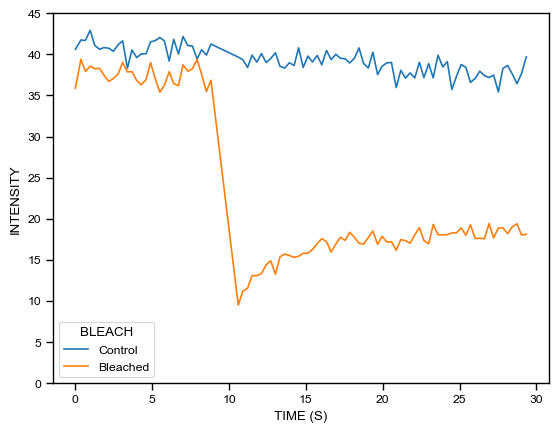

In [121]:
sns.lineplot(EG_TRACE, x = 'TIME_S', y = 'INTENSITY', hue = 'BLEACH')

plt.ylim(0,45)
plt.xlabel('TIME (S)')

## plots for talk

In [122]:
mCherry_Normalised_Data['TIME_S'] = mCherry_Normalised_Data['TIME']/1000
mClover_Normalised_Data['TIME_S'] = mClover_Normalised_Data['TIME']/1000

In [135]:
f = pd.DataFrame(dict(zip(PolAmountsPerCell.columns.tolist(), [['dummy'],['mACmChPOLR2A 5PH 90MIN'],[0.001],[0.001],[0.001],['mClover']])))

In [136]:
PolAmountsPerCell = pd.concat([PolAmountsPerCell,f])

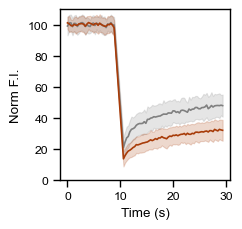

In [151]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (2.5,2.5))

cp = sns.color_palette(['grey','xkcd:rust'])

g = sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED',
                 palette = cp,
                 errorbar = 'sd',
                ax = a)


g.get_legend().remove()

a.set_ylim(0,110)
a.set_xlabel('Time (s)')
a.set_ylabel('Norm F.I.')
a.set_box_aspect(1)

plt.tight_layout()
plt.savefig('mACmChPOLR2A_FRAP_90min_trace.svg')

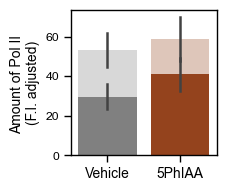

In [152]:
sns.set_context('paper')
from matplotlib.patches import Patch

f, a = plt.subplots(figsize = (2.5, 2))

cs = ['grey', 'xkcd:rust']

cps = sns.color_palette(cs)

sns.barplot(PolAmountsPerCell.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'RELATIVE_TOTAL',  
           errorbar = 'sd',
           palette = cps,
            alpha = 0.3,
           ax = a)

h = sns.barplot(PolAmountsPerCell.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'BOUND',  
           errorbar = 'sd',
           palette = cps,
           ax = a)


a.set_xlabel('')
a.set_ylabel('Amount of Pol II \n(F.I. adjusted)', fontsize = 10)
a.set_xticks(ticks = range(2), labels=['Vehicle', '5PhIAA'], fontsize = 10)



a.set_box_aspect(1)
plt.tight_layout()

plt.savefig('mACmChPOLR2A_FRAP_90min_RFPonly.svg')

In [153]:
mClover_Normalised_Data.CONDITION.unique()

array(['mACPOLR2A VEH', 'mACmChPOLR2A VEH'], dtype=object)

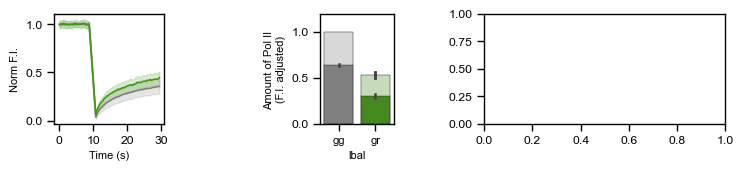

In [154]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8, 1.8))

cs = ['grey', 'xkcd:grass green']

cps = sns.color_palette(cs)

mClover_Normalised_Data['INTENSITY_NORMED_FC'] = mClover_Normalised_Data.INTENSITY_NORMED / 100

mCloverPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCloverPolAmountsPerDay['RELATIVE_TOTAL'] / 100

mCloverPolAmountsPerDay['BOUND_FC'] = mCloverPolAmountsPerDay['BOUND'] / 100


g = sns.lineplot(mClover_Normalised_Data, 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 palette = cps,
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION',
            color = 'white',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           palette = cps,
            alpha = 0.3,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

h = sns.barplot(mCloverPolAmountsPerDay, 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'BOUND_FC',  
           errorbar = 'sd',
           palette = cps,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])


a[0].set_xlabel('Time (s)', fontsize = 8)
a[0].set_ylabel('Norm F.I.', fontsize = 8)

a[0].set_xticks([0,10,20,30])

a[0].set_yticks([0,0.5,1])

a[1].set_xlabel('lbal', fontsize = 8)
a[1].set_ylabel('Amount of Pol II \n(F.I. adjusted)', fontsize = 8)
a[1].set_xticks(ticks = range(2), labels=['gg', 'gr'], fontsize = 8)
a[0].set_box_aspect(1)

a[1].set_box_aspect(1.5)

a[1].set_ylim(0,1.2)
a[1].set_yticks([0,0.5,1])

plt.tight_layout()

plt.savefig('mACmChPOLR2A_mACPOLR2A_GFP_FRAP_FC.svg')

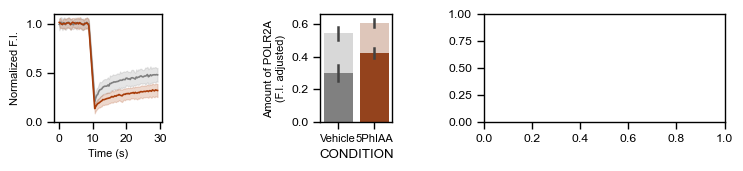

In [205]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8, 1.8))

cs = ['grey', 'xkcd:rust']

cps = sns.color_palette(cs)

mCherry_Normalised_Data['INTENSITY_NORMED_FC'] = mCherry_Normalised_Data.INTENSITY_NORMED / 100

mCherryPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCherryPolAmountsPerDay['RELATIVE_TOTAL'] / 100

mCherryPolAmountsPerDay['BOUND_FC'] = mCherryPolAmountsPerDay['BOUND'] / 100


g = sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 palette = cp,
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           palette = cps,
            alpha = 0.3,
           ax = a[1])

h = sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'BOUND_FC',  
           errorbar = 'sd',
           palette = cps,
           ax = a[1])



a[0].set_xlabel('Time (s)', fontsize = 8)
a[0].set_ylabel('Normalized F.I.', fontsize = 8)

a[0].set_xticks([0,10,20,30])

a[0].set_ylim(0, 1.1)
a[0].set_yticks([0,0.5,1])

a[1].set_ylabel('Amount of POLR2A \n(F.I. adjusted)', fontsize = 8)
a[1].set_xticks(ticks = range(2), labels=['Vehicle', '5PhIAA'], fontsize = 8)
a[0].set_box_aspect(1)

a[1].set_box_aspect(1.5)

plt.tight_layout()

plt.savefig('mACmChPOLR2A_FRAP_90min_RFPonly_FC.svg')

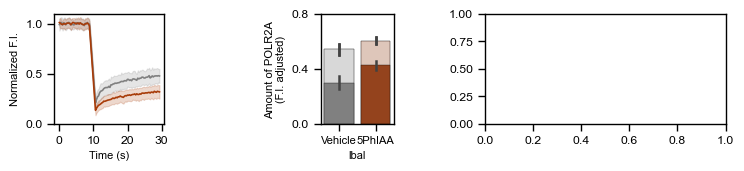

In [208]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (8, 1.8))

cs = ['grey', 'xkcd:rust']

cps = sns.color_palette(cs)

mCherry_Normalised_Data['INTENSITY_NORMED_FC'] = mCherry_Normalised_Data.INTENSITY_NORMED / 100

mCherryPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCherryPolAmountsPerDay['RELATIVE_TOTAL'] / 100

mCherryPolAmountsPerDay['BOUND_FC'] = mCherryPolAmountsPerDay['BOUND'] / 100


g = sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
             hue = 'CONDITION', 
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 palette = cps,
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            color = 'white',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           palette = cps,
            alpha = 0.3,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

h = sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH" | CONDITION == "mACmChPOLR2A 5PH 90MIN" '), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'BOUND_FC',  
           errorbar = 'sd',
           palette = cps,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])



a[0].set_xlabel('Time (s)', fontsize = 8)
a[0].set_ylabel('Normalized F.I.', fontsize = 8)

a[0].set_xticks([0,10,20,30])

a[0].set_ylim(0,1.1)
a[0].set_yticks([0,0.5,1])

a[1].set_xlabel('lbal', fontsize = 8)
a[1].set_ylabel('Amount of POLR2A \n(F.I. adjusted)', fontsize = 8)
a[1].set_xticks(ticks = range(2), labels=['Vehicle', '5PhIAA'], fontsize = 8)
a[0].set_box_aspect(1)

a[1].set_box_aspect(1.5)

a[1].set_ylim(0,0.8)
a[1].set_yticks([0,0.4,0.8])

plt.tight_layout()

plt.savefig('mACmChPOLR2A_FRAP_90min_RFPonly_FC.svg')

In [157]:
mCherryPolAmountsPerDay.CONDITION.unique()

array(['mACmChPOLR2A VEH', 'mACmChPOLR2A 5PH 24HR', 'mChPOLR2A VEH',
       'mACmChPOLR2A 5PH 90MIN'], dtype=object)

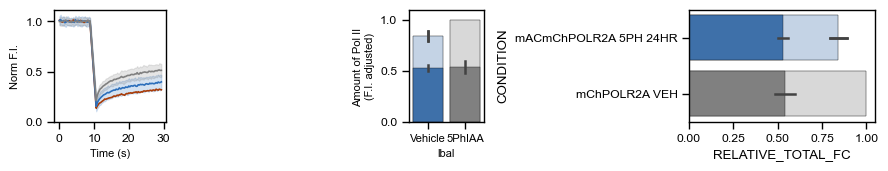

In [158]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (9, 1.8))

mCherry_Normalised_Data['INTENSITY_NORMED_FC'] = mCherry_Normalised_Data.INTENSITY_NORMED / 100

mCherryPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCherryPolAmountsPerDay['RELATIVE_TOTAL'] / 100

mCherryPolAmountsPerDay['BOUND_FC'] = mCherryPolAmountsPerDay['BOUND'] / 100


g = sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"'), 
                 x = 'TIME_S', 
                 y = 'INTENSITY_NORMED_FC',
                 color = 'xkcd:rust',
                 errorbar = None,
                 ax = a[0],
                 legend = False)

g = sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mACmChPOLR2A 5PH 24HR"'), 
             color = 'xkcd:medium blue',
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

g = sns.lineplot(mCherry_Normalised_Data.query('CONDITION == "mChPOLR2A VEH"'), 
             color = 'grey',
             x = 'TIME_S', 
             y = 'INTENSITY_NORMED_FC',
                 
                 errorbar = 'sd',
                ax = a[0],
                 legend = False)

cs2 = ['xkcd:medium blue', 'grey']

cps2 = sns.color_palette(cs2)

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            x = 'CONDITION',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           color = 'white',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           palette = cps2,
            alpha = 0.3,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])

h = sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            x = 'CONDITION',
            hue = 'CONDITION',
            y = 'BOUND_FC',  
           errorbar = 'sd',
           palette = cps2,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[1])



a[0].set_xlabel('Time (s)', fontsize = 8)
a[0].set_ylabel('Norm F.I.', fontsize = 8)

a[0].set_xticks([0,10,20,30])

a[0].set_yticks([0,0.5,1])

a[1].set_xlabel('lbal', fontsize = 8)
a[1].set_ylabel('Amount of Pol II \n(F.I. adjusted)', fontsize = 8)
a[1].set_xticks(ticks = range(2), labels=['Vehicle', '5PhIAA'], fontsize = 8)
a[0].set_box_aspect(1)

a[1].set_box_aspect(1.5)

a[1].set_ylim(0,1.1)
a[1].set_yticks([0,0.5,1])

cs2 = ['xkcd:medium blue', 'grey']

cps2 = sns.color_palette(cs2)

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            y = 'CONDITION',
            x = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           color = 'white',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[2])

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            y = 'CONDITION',
            hue = 'CONDITION',
            x = 'RELATIVE_TOTAL_FC',  
           errorbar = 'sd',
           palette = cps2,
            alpha = 0.3,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[2])

h = sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            y = 'CONDITION',
            hue = 'CONDITION',
            x = 'BOUND_FC',  
           errorbar = 'sd',
           palette = cps2,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[2])


plt.tight_layout()

plt.savefig('mACmChPOLR2A_FRAP_24hours_RFPonly_FC.svg')

In [159]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

In [160]:
print(plt.rcParams["font.sans-serif"][0])
print(plt.rcParams["font.monospace"][0])

Arial
DejaVu Sans Mono


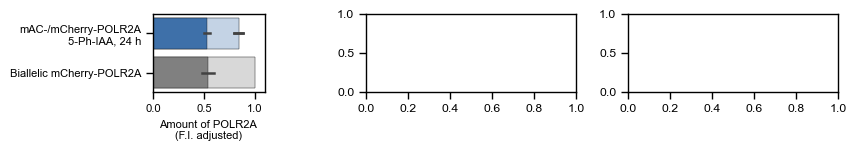

In [161]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 3, figsize = (9, 1.6))

mCherry_Normalised_Data['INTENSITY_NORMED_FC'] = mCherry_Normalised_Data.INTENSITY_NORMED / 100

mCherryPolAmountsPerDay['RELATIVE_TOTAL_FC'] = mCherryPolAmountsPerDay['RELATIVE_TOTAL'] / 100

mCherryPolAmountsPerDay['BOUND_FC'] = mCherryPolAmountsPerDay['BOUND'] / 100

cs2 = ['xkcd:medium blue', 'grey']

cps2 = sns.color_palette(cs2)

sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            x = 'RELATIVE_TOTAL_FC',  
            y = 'CONDITION',  
           errorbar = 'sd',
           color = 'white',
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[0])


sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'),
            x = 'RELATIVE_TOTAL_FC',  
            y = 'CONDITION', hue = 'CONDITION',
           errorbar = 'sd',
           palette = cps2,
            alpha = 0.3,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[0])

h = sns.barplot(mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 24HR"| CONDITION == "mChPOLR2A VEH"'), 
            y = 'CONDITION',
            hue = 'CONDITION',
            x = 'BOUND_FC',  
           errorbar = 'sd',
           palette = cps2,
            edgecolor = 'black',
            linewidth = 0.25,
            ax = a[0])

a[0].set_ylabel('', fontsize = 8)
a[0].set_yticks([0,1], labels = ['mAC-/mCherry-POLR2A\n5-Ph-IAA, 24 h','Biallelic mCherry-POLR2A'])
a[0].set_xlabel('Amount of POLR2A \n(F.I. adjusted)', fontsize = 8)
a[0].set_box_aspect(0.7)

a[0].set_xlim(0,1.1)
a[0].set_xticks([0,0.5,1])

a[0].tick_params(axis = 'both', labelsize = 8)


plt.tight_layout()

plt.savefig('mACmChPOLR2A_FRAP_24hours_RFPonly_FC_rotate.svg')

In [162]:
mCloverPolAmountsPerDay['mClover_RELATIVE_TOTAL_FC'] = mCloverPolAmountsPerDay['RELATIVE_TOTAL'] / 100
mCloverPolAmountsPerDay['mClover_BOUND_FC'] = mCloverPolAmountsPerDay['BOUND'] / 100

In [163]:
mCloverPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH"')

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE,RELATIVE_TOTAL_FC,BOUND_FC,mClover_RELATIVE_TOTAL_FC,mClover_BOUND_FC
1,250113,mACmChPOLR2A VEH,49.770611,27.417895,22.352716,0.497706,0.274179,0.497706,0.274179
3,250123,mACmChPOLR2A VEH,55.922269,32.317502,23.604768,0.559223,0.323175,0.559223,0.323175
5,250124,mACmChPOLR2A VEH,53.855441,31.375279,22.480162,0.538554,0.313753,0.538554,0.313753


In [164]:
mACmCh_Vehicle_mCh = mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH"')[['DATE','CONDITION','RELATIVE_TOTAL_FC','BOUND_FC']]

In [165]:
mACmCh_Vehicle_mCh.rename(columns = {"RELATIVE_TOTAL_FC" : "mCherry_RELATIVE_TOTAL_FC",
                                    "BOUND_FC" : "mCherry_BOUND_FC",}, inplace = True)

In [166]:
mACmCh_Vehicle_mAC = mCloverPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH"')[['DATE','CONDITION','mClover_RELATIVE_TOTAL_FC','mClover_BOUND_FC']]

In [167]:
mACmCh_Vehicle_mAC 

,DATE,CONDITION,mClover_RELATIVE_TOTAL_FC,mClover_BOUND_FC
1,250113,mACmChPOLR2A VEH,0.497706,0.274179
3,250123,mACmChPOLR2A VEH,0.559223,0.323175
5,250124,mACmChPOLR2A VEH,0.538554,0.313753


In [168]:
mCherryplusmClover_AmountsPerDay = mACmCh_Vehicle_mCh.merge(mACmCh_Vehicle_mAC)

In [169]:
mCherryplusmClover_AmountsPerDay['RFPGFP_TOTAL'] = mCherryplusmClover_AmountsPerDay.mCherry_RELATIVE_TOTAL_FC + mCherryplusmClover_AmountsPerDay.mClover_RELATIVE_TOTAL_FC
mCherryplusmClover_AmountsPerDay['RFPGFP_BOUND'] = mCherryplusmClover_AmountsPerDay.mCherry_BOUND_FC + mCherryplusmClover_AmountsPerDay.mClover_BOUND_FC

In [170]:
mCherryplusmClover_AmountsPerDay['RFPGFP_BOUND_FRACTION'] = mCherryplusmClover_AmountsPerDay['RFPGFP_BOUND'] / mCherryplusmClover_AmountsPerDay['RFPGFP_TOTAL']
mCherryplusmClover_AmountsPerDay['RFPGFP_FREE_FRACTION'] = 1 - mCherryplusmClover_AmountsPerDay['RFPGFP_BOUND_FRACTION']

In [171]:
vals_baseline = mCherryplusmClover_AmountsPerDay.drop('DATE',axis = 1).groupby('CONDITION').mean().reset_index()
vals_baseline['RFPGFP_TOTAL_STD'] = mCherryplusmClover_AmountsPerDay.drop('DATE',axis = 1).groupby('CONDITION').std().reset_index()['RFPGFP_TOTAL']
vals_baseline['RFPGFP_BOUND_STD'] = mCherryplusmClover_AmountsPerDay.drop('DATE',axis = 1).groupby('CONDITION').std().reset_index()['RFPGFP_BOUND']
vals_baseline['RFPGFP_BOUND_FRACTION_STD'] = mCherryplusmClover_AmountsPerDay.drop('DATE',axis = 1).groupby('CONDITION').std().reset_index()['RFPGFP_BOUND_FRACTION']
vals_baseline['RFPGFP_FREE_FRACTION_STD'] = mCherryplusmClover_AmountsPerDay.drop('DATE',axis = 1).groupby('CONDITION').std().reset_index()['RFPGFP_FREE_FRACTION']

In [172]:
mCherryPolAmountsPerDay['BOUND_FRACTION'] = mCherryPolAmountsPerDay['BOUND'] / mCherryPolAmountsPerDay['RELATIVE_TOTAL']
mCherryPolAmountsPerDay['FREE_FRACTION'] = 1 - mCherryPolAmountsPerDay['BOUND_FRACTION']

In [173]:
vals_5ph = mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"').drop('DATE', axis = 1).groupby('CONDITION').mean().reset_index()
vals_5ph['RELATIVE_TOTAL_FC_STD'] = mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"').drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['RELATIVE_TOTAL_FC']
vals_5ph['BOUND_FC_STD'] = mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"').drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['BOUND_FC']
vals_5ph['BOUND_FRACTION_STD'] = mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"').drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['BOUND_FRACTION']
vals_5ph['FREE_FRACTION_STD'] = mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"').drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['FREE_FRACTION']

In [174]:
vals_5ph

,CONDITION,RELATIVE_TOTAL,BOUND,FREE,RELATIVE_TOTAL_FC,BOUND_FC,BOUND_FRACTION,FREE_FRACTION,RELATIVE_TOTAL_FC_STD,BOUND_FC_STD,BOUND_FRACTION_STD,FREE_FRACTION_STD
0,mACmChPOLR2A 5PH 90MIN,60.499207,42.450934,18.048273,0.604992,0.424509,0.701111,0.298889,0.025424,0.030472,0.020694,0.020694


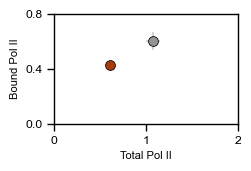

In [175]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = vals_baseline.RFPGFP_TOTAL,
              xerr = vals_baseline.RFPGFP_TOTAL_STD,
              y = vals_baseline.RFPGFP_BOUND,
              yerr = vals_baseline.RFPGFP_BOUND_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

a.errorbar(x = vals_5ph.RELATIVE_TOTAL_FC,
           xerr = vals_5ph.RELATIVE_TOTAL_FC_STD,
           y = vals_5ph.BOUND_FC,
           yerr = vals_5ph.BOUND_FC_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')


h = sns.scatterplot(x = vals_baseline.RFPGFP_TOTAL,
                y = vals_baseline.RFPGFP_BOUND,
                ax = a,
                color = 'xkcd:grey',
                    s = 50, edgecolor = 'black',
                    legend = False)

h = sns.scatterplot(x = vals_5ph.RELATIVE_TOTAL_FC,
                y = vals_5ph.BOUND_FC,
                ax = a,
                color = 'xkcd:rust',
                    s = 50, edgecolor = 'black',
                    legend = False)


a.set_box_aspect(0.6)
a.set_ylim(0,0.8)
a.set_yticks([0,0.4,0.8])
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])


a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('Bound Pol II', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_bound_mACmCh.svg')

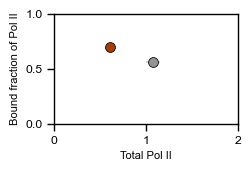

In [176]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = vals_baseline.RFPGFP_TOTAL,
              xerr = vals_baseline.RFPGFP_TOTAL_STD,
              y = vals_baseline.RFPGFP_BOUND_FRACTION,
              yerr = vals_baseline.RFPGFP_BOUND_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

a.errorbar(x = vals_5ph.RELATIVE_TOTAL_FC,
           xerr = vals_5ph.RELATIVE_TOTAL_FC_STD,
           y = vals_5ph.BOUND_FRACTION,
           yerr = vals_5ph.BOUND_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')


h = sns.scatterplot(x = vals_baseline.RFPGFP_TOTAL,
                y = vals_baseline.RFPGFP_BOUND_FRACTION,
                ax = a,
                color = 'xkcd:grey',
                    s = 50, edgecolor = 'black',
                    legend = False)

h = sns.scatterplot(x = vals_5ph.RELATIVE_TOTAL_FC,
                y = vals_5ph.BOUND_FRACTION,
                ax = a,
                color = 'xkcd:rust',
                    s = 50, edgecolor = 'black',
                    legend = False)


a.set_box_aspect(0.6)
a.set_ylim(0,1)
a.set_yticks([0,0.5,1])
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])


a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('Bound fraction of Pol II', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_bound_fraction_mACmCh.svg')

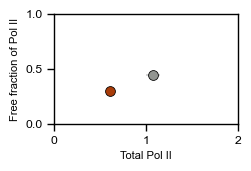

In [177]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = vals_baseline.RFPGFP_TOTAL,
              xerr = vals_baseline.RFPGFP_TOTAL_STD,
              y = vals_baseline.RFPGFP_FREE_FRACTION,
              yerr = vals_baseline.RFPGFP_FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

a.errorbar(x = vals_5ph.RELATIVE_TOTAL_FC,
           xerr = vals_5ph.RELATIVE_TOTAL_FC_STD,
           y = vals_5ph.FREE_FRACTION,
           yerr = vals_5ph.FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')


h = sns.scatterplot(x = vals_baseline.RFPGFP_TOTAL,
                y = vals_baseline.RFPGFP_FREE_FRACTION,
                ax = a,
                color = 'xkcd:grey',
                    s = 50, edgecolor = 'black',
                    legend = False)

h = sns.scatterplot(x = vals_5ph.RELATIVE_TOTAL_FC,
                y = vals_5ph.FREE_FRACTION,
                ax = a,
                color = 'xkcd:rust',
                    s = 50, edgecolor = 'black',
                    legend = False)


a.set_box_aspect(0.6)
a.set_ylim(0,1)
a.set_yticks([0,0.5,1])
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])


a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('Free fraction of Pol II', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_free_fraction_mACmCh.svg')

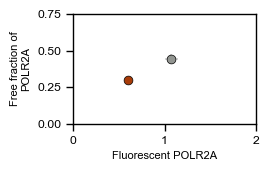

In [178]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = vals_baseline.RFPGFP_TOTAL,
              xerr = vals_baseline.RFPGFP_TOTAL_STD,
              y = vals_baseline.RFPGFP_FREE_FRACTION,
              yerr = vals_baseline.RFPGFP_FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

a.errorbar(x = vals_5ph.RELATIVE_TOTAL_FC,
           xerr = vals_5ph.RELATIVE_TOTAL_FC_STD,
           y = vals_5ph.FREE_FRACTION,
           yerr = vals_5ph.FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')


h = sns.scatterplot(x = vals_baseline.RFPGFP_TOTAL,
                y = vals_baseline.RFPGFP_FREE_FRACTION,
                ax = a,
                color = 'xkcd:grey',
                    s = 40, edgecolor = 'black',
                    legend = False)

h = sns.scatterplot(x = vals_5ph.RELATIVE_TOTAL_FC,
                y = vals_5ph.FREE_FRACTION,
                ax = a,
                color = 'xkcd:rust',
                    s = 40, edgecolor = 'black',
                    legend = False)


a.set_box_aspect(0.6)
a.set_ylim(0,0.75)
a.set_yticks([0, 0.25, 0.5, 0.75])
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])


a.set_xlabel('Fluorescent POLR2A', fontsize = 8)

a.set_ylabel('Free fraction of\nPOLR2A', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_free_fraction_mACmCh_yscale.svg')

In [179]:
xvals = mCherryPolAmountsPerDay.drop('DATE', axis = 1).groupby('CONDITION').mean().reset_index()
xvals['RELATIVE_TOTAL_FC_STD'] = mCherryPolAmountsPerDay.drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['RELATIVE_TOTAL_FC']
xvals['BOUND_FC_STD'] = mCherryPolAmountsPerDay.drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['BOUND_FC']
xvals['BOUND_FRACTION_STD'] = mCherryPolAmountsPerDay.drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['BOUND_FRACTION']
xvals['FREE_FRACTION_STD'] = mCherryPolAmountsPerDay.drop('DATE', axis = 1).groupby('CONDITION').std().reset_index()['FREE_FRACTION']

In [180]:
xvals = xvals.query('CONDITION != "mACmChPOLR2A VEH"')

In [181]:
xvals.CONDITION.unique()

array(['mACmChPOLR2A 5PH 24HR', 'mACmChPOLR2A 5PH 90MIN', 'mChPOLR2A VEH'],
      dtype=object)

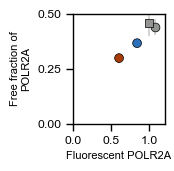

In [182]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5, 1.8))

a.errorbar(x = vals_baseline.RFPGFP_TOTAL,
              xerr = vals_baseline.RFPGFP_TOTAL_STD,
              y = vals_baseline.RFPGFP_FREE_FRACTION,
              yerr = vals_baseline.RFPGFP_FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

a.errorbar(x = xvals.RELATIVE_TOTAL_FC,
              xerr = xvals.RELATIVE_TOTAL_FC_STD,
              y = xvals.FREE_FRACTION,
              yerr = xvals.FREE_FRACTION_STD,
              linestyle = "None",
              alpha = 0.4, zorder = 1,
              color = 'grey')

h = sns.scatterplot(x = vals_baseline.RFPGFP_TOTAL,
                y = vals_baseline.RFPGFP_FREE_FRACTION,
                ax = a,
                color = 'xkcd:grey',
                    s = 40, edgecolor = 'black',
                    legend = False)

h = sns.scatterplot(xvals.query('CONDITION != "mChPOLR2A VEH"'),
                    x = 'RELATIVE_TOTAL_FC',
                    y = 'FREE_FRACTION',
                    hue = 'CONDITION',
                    palette = sns.color_palette(['xkcd:medium blue', 'xkcd:rust']),
                ax = a,
                    s = 40, edgecolor = 'black',
                    legend = False)

h = sns.scatterplot(xvals.query('CONDITION == "mChPOLR2A VEH"'),
                    x = 'RELATIVE_TOTAL_FC',
                    y = 'FREE_FRACTION',
                    color = 'xkcd:grey',
                    marker = 's',
                    ax = a,
                    s = 40, edgecolor = 'black',
                    legend = False)


a.set_box_aspect(1.2)
a.set_ylim(0,0.5)
a.set_yticks([0, 0.25, 0.5])
a.set_xlim(0,1.2)
a.set_xticks([0,0.5, 1.0])


a.set_xlabel('Fluorescent POLR2A', fontsize = 8)

a.set_ylabel('Free fraction of\nPOLR2A', fontsize = 8)


plt.tight_layout()


plt.savefig('total_vs_free_fraction_mACmCh_24hr_yscale.svg')

In [186]:
mCloverPolAmountsPerDay.to_csv('mACmChPOLR2A_mClover3_FRAP_Amounts_perday.csv')

In [187]:
mCherryPolAmountsPerDay.to_csv('mACmChPOLR2A_FRAP_Amounts_perday.csv')

In [188]:
mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A VEH"')

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE,RELATIVE_TOTAL_FC,BOUND_FC,BOUND_FRACTION,FREE_FRACTION
0,250113,mACmChPOLR2A VEH,49.638949,25.289301,24.349648,0.496389,0.252893,0.509465,0.490535
4,250123,mACmChPOLR2A VEH,56.863899,29.988220,26.875680,0.568639,0.299882,0.527368,0.472632
8,250124,mACmChPOLR2A VEH,56.459085,34.521786,21.937299,0.564591,0.345218,0.611448,0.388552


In [189]:
mCherryPolAmountsPerDay.query('CONDITION == "mACmChPOLR2A 5PH 90MIN"')

,DATE,CONDITION,RELATIVE_TOTAL,BOUND,FREE,RELATIVE_TOTAL_FC,BOUND_FC,BOUND_FRACTION,FREE_FRACTION
3,250113,mACmChPOLR2A 5PH 90MIN,58.942836,40.851153,18.091683,0.589428,0.408512,0.693064,0.306936
7,250123,mACmChPOLR2A 5PH 90MIN,63.433139,45.964890,17.468248,0.634331,0.459649,0.724620,0.275380
11,250124,mACmChPOLR2A 5PH 90MIN,59.121647,40.536759,18.584888,0.591216,0.405368,0.685650,0.314350


In [190]:
increase = [100*40.851153 / 25.289301, 100*45.964890 / 29.988220, 100*40.536759 / 34.521786]

In [191]:
np.mean(increase), np.std(increase)

(144.07850235172006, 19.146990669718143)

In [192]:
mCherryPolAmountsPerDay.drop('DATE',axis = 1).groupby('CONDITION').std()

,RELATIVE_TOTAL,BOUND,FREE,RELATIVE_TOTAL_FC,BOUND_FC,BOUND_FRACTION,FREE_FRACTION
CONDITION,,,,,,,
mACmChPOLR2A 5PH 24HR,4.807425,2.845161,2.481319,0.048074,0.028452,0.014330,0.014330
mACmChPOLR2A 5PH 90MIN,2.542432,3.047233,0.559584,0.025424,0.030472,0.020694,0.020694
mACmChPOLR2A VEH,4.059516,4.616489,2.469408,0.040595,0.046165,0.054452,0.054452
mChPOLR2A VEH,0.000000,5.820101,5.820101,0.000000,0.058201,0.058201,0.058201


In [193]:
mCherry_On_DF

,DATE,CONDITION,FILE,AREA,INTENSITY_MCHERRY,INTENSITY_MCLOVER
0,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,22390,16.363945,10.637779
1,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,17738,15.723805,8.477366
2,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,16421,15.269736,8.281718
3,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,16406,17.014038,10.585212
4,250113,mACmChPOLR2A VEH,250113_mACmChPOLR2A_FRAP/WELL03_mACmChPOLR2A_V...,13053,14.473933,9.543393
...,...,...,...,...,...,...
175,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,15984,29.957269,0.747533
176,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,18633,30.792919,0.942392
177,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,14182,28.534446,0.634483
178,250124,mChPOLR2A VEH,250124_mACmChPOLR2A_FRAP/WELL07_mChPOLR2A_VEH_...,16005,32.074407,1.051759
